In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.patches as patches
import time
from numba import jit,njit,prange
from IPython.core.display import display, HTML
from matplotlib.animation import FuncAnimation
from tqdm.notebook import tqdm

display(HTML("<style>.container {width: 90% !important; }</style>"))

%matplotlib notebook

In [2]:
@njit(fastmath=True)
def extrapolate_3rd(x1,x2,x3):
    return 3*x1-3*x2+x3

In [3]:
@njit(fastmath=True)
def extrapolate_4th(x1,x2,x3,x4):
    return 4*x1-6*x2+4*x3-x4

In [4]:
@njit(fastmath=True)
def face_interpolate_4th(x1,x2,x3,x4):
    return (-x1+9*x2+9*x3-x4)/16

In [5]:
@njit(fastmath=True)
def diff_interpolate_4th(x1,x2,x3,x4,h):
    #h denotes grid spacing
    return (x1-27*x2+27*x3-x4)/(24*h)

In [6]:
@njit(fastmath=True)
def p_face(Ny,Nx,P):
    
    Pxf=np.zeros((Ny,Nx+1))
    Pyf=np.zeros((Ny+1,Nx))
    
    #horizontal faces
    for j in range(Ny):
        i=0
        
        PP=P[j][i]
        PE=P[j][i+1]
        Pxf[j][i]=1.5*PP-0.5*PE
        
        for i in range(1,Nx):
            PP=P[j][i-1]
            PE=P[j][i]
            Pxf[j][i]=0.5*(PP+PE)
            
        i=Nx
        
        PP=P[j][i-1]
        PW=P[j][i-2]
        Pxf[j][i]=1.5*PP-0.5*PW

    #vertical faces
    for i in range(Nx):
        j=0
        PP=P[j][i]
        PN=P[j+1][i]
        Pyf[j][i]=1.5*PP-0.5*PN
        
        for j in range(1,Ny):
            PP=P[j-1][i]
            PN=P[j][i]
            Pyf[j][i]=0.5*(PP+PN)
            
        j=Ny
        PP=P[j-1][i]
        PS=P[j-2][i]
        Pyf[j][i]=1.5*PP-0.5*PS
            
    return Pxf,Pyf

In [7]:
@njit(fastmath=True)
def face_centre(Ny,Nx,phi,scalar):
    
    phi_xf=np.zeros((Ny,Nx+1)) #vertical faces
    phi_yf=np.zeros((Ny+1,Nx)) #horizontal faces
    
    #vertical faces
    for j in range(Ny):
        i=1 #left wall
        
        phi_W=phi[j][i-1]
        phi_P=phi[j][i]
        phi_E=phi[j][i+1]
        phi_EE=phi[j][i+2]
        phi_WW=extrapolate_4th(phi_W,phi_P,phi_E,phi_EE)
        phi_WWW=extrapolate_4th(phi_WW,phi_W,phi_P,phi_E)
        
        phi_xf[j][i]=face_interpolate_4th(phi_WW,phi_W,phi_P,phi_E)
        phi_xf[j][i-1]=face_interpolate_4th(phi_WWW,phi_WW,phi_W,phi_P)

        for i in range(2,Nx-1):
            phi_WW=phi[j][i-2]
            phi_W=phi[j][i-1]
            phi_P=phi[j][i]
            phi_E=phi[j][i+1]

            phi_xf[j][i]=face_interpolate_4th(phi_WW,phi_W,phi_P,phi_E)
            
        i=Nx-1 #right wall
        
        phi_P=phi[j][i]
        phi_W=phi[j][i-1]
        phi_WW=phi[j][i-2]
        phi_WWW=phi[j][i-3]
        phi_E=extrapolate_4th(phi_P,phi_W,phi_WW,phi_WWW)
        phi_EE=extrapolate_4th(phi_E,phi_P,phi_W,phi_WW)
        
        phi_xf[j][i]=face_interpolate_4th(phi_WW,phi_W,phi_P,phi_E)
        phi_xf[j][i+1]=face_interpolate_4th(phi_W,phi_P,phi_E,phi_EE)
    
    #horizontal faces
    for i in range(Nx):
        j=0 #bottom wall
        
        phi_P=phi[j][i]
        phi_N=phi[j+1][i]
        phi_NN=phi[j+2][i]
        phi_NNN=phi[j+3][i]
        phi_S=extrapolate_4th(phi_P,phi_N,phi_NN,phi_NNN)
        phi_SS=extrapolate_4th(phi_S,phi_P,phi_N,phi_NN)
        
        phi_yf[j][i]=face_interpolate_4th(phi_SS,phi_S,phi_P,phi_N)
        phi_yf[j+1][i]=face_interpolate_4th(phi_S,phi_P,phi_N,phi_NN)
        
        for j in range(2,Ny-1):
            phi_SS=phi[j-2][i]
            phi_S=phi[j-1][i]
            phi_P=phi[j][i]
            phi_N=phi[j+1][i]

            phi_yf[j][i]=face_interpolate_4th(phi_SS,phi_S,phi_P,phi_N)
            
        j=Ny #top wall
        
        phi_S=phi[j-1][i]
        phi_SS=phi[j-2][i]
        phi_SSS=phi[j-3][i]
        phi_SSSS=phi[j-4][i]
        phi_P=extrapolate_4th(phi_S,phi_SS,phi_SSS,phi_SSSS)
        phi_N=extrapolate_4th(phi_P,phi_S,phi_SS,phi_SSS)
        
        phi_yf[j][i]=face_interpolate_4th(phi_SS,phi_S,phi_P,phi_N)
        phi_yf[j-1][i]=face_interpolate_4th(phi_SSS,phi_SS,phi_S,phi_P)
        
    #set boundaries for various scalars
    
    if scalar==0: #velocity
        #top and bottom wall
        for i in range(Nx):
            phi_yf[0][i]=0
            phi_yf[-1][i]=0
        #left and right wall
        for j in range(Ny):
            phi_xf[j][0]=0
            phi_xf[j][-1]=0
            
    if scalar==1: #temperature
        for j in range(Ny):
            phi_xf[j][0]=1.0
            phi_xf[j][-1]=0.0
            
    return phi_xf,phi_yf

In [8]:
@njit(fastmath=True)
def vertex(Ny,Nx,phi_xf,phi_yf,scalar):
    #only used phi_yf (horizontal faces) to compute vertex values
    vertex_field=np.zeros((Ny+1,Nx+1))

    for j in range(Ny+1):
        #inlet
        i=1
        
        phi_w=phi_yf[j][i-1]
        phi_p=phi_yf[j][i]
        phi_e=phi_yf[j][i+1]
        phi_ee=phi_yf[j][i+2]
        phi_ww=extrapolate_4th(phi_w,phi_p,phi_e,phi_ee)
        phi_www=extrapolate_4th(phi_ww,phi_w,phi_p,phi_e)
        
        vertex_field[j][i]=face_interpolate_4th(phi_ww,phi_w,phi_p,phi_e)
        vertex_field[j][i-1]=face_interpolate_4th(phi_www,phi_ww,phi_w,phi_p)
        
        for i in range(2,Nx-1):
            phi_ww=phi_yf[j][i-2]
            phi_w=phi_yf[j][i-1]
            phi_p=phi_yf[j][i]
            phi_e=phi_yf[j][i+1]
            
            vertex_field[j][i]=face_interpolate_4th(phi_ww,phi_w,phi_p,phi_e)
        
        #right wall
        i=Nx-1
        
        phi_p=phi_yf[j][i]
        phi_w=phi_yf[j][i-1]
        phi_ww=phi_yf[j][i-2]
        phi_www=phi_yf[j][i-3]
        phi_e=extrapolate_4th(phi_p,phi_w,phi_ww,phi_www)
        phi_ee=extrapolate_4th(phi_e,phi_p,phi_w,phi_ww)
        
        vertex_field[j][i]=face_interpolate_4th(phi_ww,phi_w,phi_p,phi_e)
        vertex_field[j][i+1]=face_interpolate_4th(phi_w,phi_p,phi_e,phi_ee)
        
    if scalar==0: #velocity
        #left and right wall
        for j in range(Ny+1):
            vertex_field[j][0]=0.0
            vertex_field[j][-1]=0.0
        #top and btm wall
        for i in range(Nx+1):
            vertex_field[0][i]=0.0
            vertex_field[Ny][i]=0.0
                
    elif scalar==1: #temperature
#         #top and btm wall
#         for i in range(Nx+1):
#             vertex_field[0][i]=1.0
#             vertex_field[Ny][i]=0.0
            
        #left and right wall
        for j in range(Nx+1):
            vertex_field[j][0]=1.0
            vertex_field[j][-1]=0.0
            
    elif scalar==2: #pressure
        for i in range(Nx):
            j=0
            phi_p=phi_xf[j][i]
            phi_n=phi_xf[j+1][i]
            phi_nn=phi_xf[j+2][i]
            phi_nnn=phi_xf[j+3][i]
            phi_s=extrapolate_4th(phi_p,phi_n,phi_nn,phi_nnn)
            phi_ss=extrapolate_4th(phi_s,phi_p,phi_n,phi_nn)
            
            vertex_field[j][i]=face_interpolate_4th(phi_ss,phi_s,phi_p,phi_n)
            vertex_field[j+1][i]=face_interpolate_4th(phi_s,phi_p,phi_n,phi_nn)
            
            j=Ny
            phi_s=phi_xf[j-1][i]
            phi_ss=phi_xf[j-2][i]
            phi_sss=phi_xf[j-3][i]
            phi_ssss=phi_xf[j-4][i]
            phi_p=extrapolate_4th(phi_s,phi_ss,phi_sss,phi_ssss)
            phi_n=extrapolate_4th(phi_p,phi_ss,phi_ss,phi_sss)
            
            vertex_field[j][i]=face_interpolate_4th(phi_ss,phi_s,phi_p,phi_n)
            vertex_field[j-1][i]=face_interpolate_4th(phi_sss,phi_ss,phi_s,phi_p)
                                    
    return vertex_field

In [9]:
@njit(fastmath=True)
def simp_rule(Ny,Nx,phi_xf,phi_yf,vertex_field):
    #use simpson rule to calculate surface integral
    
    phi_xf_simp=np.zeros((Ny,Nx+1)) #vertical faces
    phi_yf_simp=np.zeros((Ny+1,Nx)) #horizontal faces
    
    #vertical faces
    for j in range(Ny):
        for i in range(Nx+1):
            phi_face=phi_xf[j][i]
            phi_vert_top=vertex_field[j+1][i]
            phi_vert_btm=vertex_field[j][i]
            
            phi_xf_simp[j][i]=(phi_vert_top+4*phi_face+phi_vert_btm)/6
            
    #horizontal faces
    for j in range(Ny+1):
        for i in range(Nx):
            phi_face=phi_yf[j][i]
            phi_vert_left=vertex_field[j][i]
            phi_vert_rgt=vertex_field[j][i+1]
            
            phi_yf_simp[j][i]=(phi_vert_left+4*phi_face+phi_vert_rgt)/6
            
    return phi_xf_simp,phi_yf_simp

In [10]:
def conv_face(Ny,Nx,phi,scalar):
    phi_xf,phi_yf=face_centre(Ny,Nx,phi,scalar)
    vertex_field=vertex(Ny,Nx,phi_xf,phi_yf,scalar)
    phi_xf,phi_yf=simp_rule(Ny,Nx,phi_xf,phi_yf,vertex_field)
    return phi_xf,phi_yf,vertex_field

In [11]:
@njit(fastmath=True,parallel=False)
def diff_face_centre(Ny,Nx,phi_xf,phi_yf,phi,dx,dy,scalar):
    
    #vertical faces
    for j in range(Ny):
        i=0 #left
        phi_P=phi[j][i]
        phi_E=phi[j][i+1]
        phi_EE=phi[j][i+2]
        phi_EEE=phi[j][i+3]
        phi_W=extrapolate_4th(phi_P,phi_E,phi_EE,phi_EEE)
        phi_WW=extrapolate_4th(phi_W,phi_P,phi_E,phi_EE)
        
        phi_xf[j][i]=diff_interpolate_4th(phi_WW,phi_W,phi_P,phi_E,dx)
        phi_xf[j][i+1]=diff_interpolate_4th(phi_W,phi_P,phi_E,phi_EE,dx)
        
        for i in range(2,Nx-1):
            phi_WW=phi[j][i-2]
            phi_W=phi[j][i-1]
            phi_P=phi[j][i]
            phi_E=phi[j][i+1]

            phi_xf[j][i]=diff_interpolate_4th(phi_WW,phi_W,phi_P,phi_E,dx)
            
        i=Nx #right
        
        phi_W=phi[j][i-1]
        phi_WW=phi[j][i-2]
        phi_WWW=phi[j][i-3]
        phi_WWWW=phi[j][i-4]
        phi_P=extrapolate_4th(phi_W,phi_WW,phi_WWW,phi_WWWW)
        phi_E=extrapolate_4th(phi_P,phi_W,phi_WW,phi_WWW)
        
        phi_xf[j][i]=diff_interpolate_4th(phi_WW,phi_W,phi_P,phi_E,dx)
        phi_xf[j][i-1]=diff_interpolate_4th(phi_WWW,phi_WW,phi_W,phi_P,dx)
    
    #horizontal faces
    for i in range(Nx):
        j=0 #bottom wall
        
        phi_P=phi[j][i]
        phi_N=phi[j+1][i]
        phi_NN=phi[j+2][i]
        phi_NNN=phi[j+3][i]
        phi_S=extrapolate_4th(phi_P,phi_N,phi_NN,phi_NNN)
        phi_SS=extrapolate_4th(phi_S,phi_P,phi_N,phi_NN)
        
        phi_yf[j][i]=diff_interpolate_4th(phi_SS,phi_S,phi_P,phi_N,dy)
        phi_yf[j+1][i]=diff_interpolate_4th(phi_S,phi_P,phi_N,phi_NN,dy)
        
        j=Ny #top wall
        
        phi_S=phi[j-1][i]
        phi_SS=phi[j-2][i]
        phi_SSS=phi[j-3][i]
        phi_SSSS=phi[j-4][i]
        phi_P=extrapolate_4th(phi_S,phi_SS,phi_SSS,phi_SSSS)
        phi_N=extrapolate_4th(phi_P,phi_S,phi_SS,phi_SSS)
        
        phi_yf[j][i]=diff_interpolate_4th(phi_SS,phi_S,phi_P,phi_N,dy)
        phi_yf[j-1][i]=diff_interpolate_4th(phi_SSS,phi_SS,phi_S,phi_P,dy)
        
    for j in range(2,Ny-1):
        for i in range(Nx):
            phi_SS=phi[j-2][i]
            phi_S=phi[j-1][i]
            phi_P=phi[j][i]
            phi_N=phi[j+1][i]

            phi_yf[j][i]=diff_interpolate_4th(phi_SS,phi_S,phi_P,phi_N,dy)
            
    if scalar==1: #temperature
        for i in range(Nx):
            j=0
            phi_yf[j][i]=0.0
            j=Ny
            phi_yf[j][i]=0.0
                
    return phi_xf,phi_yf

In [12]:
@njit(fastmath=True,parallel=False)
def diff_vertex(Ny,Nx,vertex_field_x,vertex_field_y,phi_xf,phi_yf,dx,dy,scalar):

    #horizontal gradients
    for j in range(Ny+1):
        #left wall
        i=0
        
        phi_p=phi_yf[j][i]
        phi_e=phi_yf[j][i+1]
        phi_ee=phi_yf[j][i+2]
        phi_eee=phi_yf[j][i+3]
        phi_w=extrapolate_4th(phi_p,phi_e,phi_ee,phi_eee)
        phi_ww=extrapolate_4th(phi_w,phi_p,phi_e,phi_ee)
        
        vertex_field_x[j][i]=diff_interpolate_4th(phi_ww,phi_w,phi_p,phi_e,dx)
        vertex_field_x[j][i+1]=diff_interpolate_4th(phi_w,phi_p,phi_e,phi_ee,dx)
        
        for i in range(2,Nx-1):
            phi_ww=phi_yf[j][i-2]
            phi_w=phi_yf[j][i-1]
            phi_p=phi_yf[j][i]
            phi_e=phi_yf[j][i+1]
            
            vertex_field_x[j][i]=diff_interpolate_4th(phi_ww,phi_w,phi_p,phi_e,dx)
        
        #outlet
        i=Nx
        
        phi_w=phi_yf[j][i-1]
        phi_ww=phi_yf[j][i-2]
        phi_www=phi_yf[j][i-3]
        phi_wwww=phi_yf[j][i-4]
        phi_p=extrapolate_4th(phi_w,phi_ww,phi_www,phi_wwww)
        phi_e=extrapolate_4th(phi_p,phi_w,phi_ww,phi_www)
        
        vertex_field_x[j][i]=diff_interpolate_4th(phi_ww,phi_w,phi_p,phi_e,dx)
        vertex_field_x[j][i-1]=diff_interpolate_4th(phi_www,phi_ww,phi_w,phi_p,dx)

    #vertical gradients
    for i in range(Nx+1):   
        j=0
    
        phi_p=phi_xf[j][i]
        phi_n=phi_xf[j+1][i]
        phi_nn=phi_xf[j+2][i]
        phi_nnn=phi_xf[j+3][i]
        phi_s=extrapolate_4th(phi_p,phi_n,phi_nn,phi_nnn)
        phi_ss=extrapolate_4th(phi_s,phi_p,phi_n,phi_nn)

        vertex_field_y[j][i]=diff_interpolate_4th(phi_ss,phi_s,phi_p,phi_n,dy)
        vertex_field_y[j+1][i]=diff_interpolate_4th(phi_s,phi_p,phi_n,phi_nn,dy)
        
        for j in range(2,Ny-1):
            phi_ss=phi_xf[j-2][i]
            phi_s=phi_xf[j-1][i]
            phi_p=phi_xf[j][i]
            phi_n=phi_xf[j+1][i]
            
            vertex_field_y[j][i]=diff_interpolate_4th(phi_ss,phi_s,phi_p,phi_n,dy)

        j=Ny
        
        phi_s=phi_xf[j-1][i]
        phi_ss=phi_xf[j-2][i]
        phi_sss=phi_xf[j-3][i]
        phi_ssss=phi_xf[j-4][i]
        phi_p=extrapolate_4th(phi_s,phi_ss,phi_sss,phi_ssss)
        phi_n=extrapolate_4th(phi_p,phi_s,phi_ss,phi_sss)

        vertex_field_y[j][i]=diff_interpolate_4th(phi_ss,phi_s,phi_p,phi_n,dy)
        vertex_field_y[j-1][i]=diff_interpolate_4th(phi_sss,phi_ss,phi_s,phi_p,dy)
        
    if scalar==1: #temperature
        for i in range(Nx):
            j=0
            vertex_field_y[j][i]=0.0
            j=Ny
            vertex_field_y[j][i]=0.0
        
    return vertex_field_x,vertex_field_y

In [13]:
@njit(fastmath=True)
def diff_simp_rule(Ny,Nx,phi_xf,phi_yf,phi_xf_simp,phi_yf_simp,vertex_field_x,vertex_field_y):
    #use simpson rule to calculate surface integral
    
    #vertical faces
    for j in range(Ny):
        for i in range(Nx+1):
            phi_face=phi_xf[j][i]
            phi_vert_top=vertex_field_x[j+1][i]
            phi_vert_btm=vertex_field_x[j][i]
            
            phi_xf_simp[j][i]=(phi_vert_top+4*phi_face+phi_vert_btm)/6
            
    #horizontal faces
    for j in range(Ny+1):
        for i in range(Nx):
            phi_face=phi_yf[j][i]
            phi_vert_left=vertex_field_y[j][i]
            phi_vert_rgt=vertex_field_y[j][i+1]
            
            phi_yf_simp[j][i]=(phi_vert_left+4*phi_face+phi_vert_rgt)/6
            
    return phi_xf_simp,phi_yf_simp

In [14]:
def diff_face(Ny,Nx,phi,dx,dy,scalar):
    phi_xf=np.zeros((Ny,Nx+1)) #vertical faces
    phi_yf=np.zeros((Ny+1,Nx)) #horizontal faces 
    phi_xf_diff=np.zeros((Ny,Nx+1)) #vertical faces
    phi_yf_diff=np.zeros((Ny+1,Nx)) #horizontal faces 
    vertex_field_x=np.zeros((Ny+1,Nx+1)) #vertices
    vertex_field_y=np.zeros((Ny+1,Nx+1)) #vertices
    phi_xf_out=np.zeros((Ny,Nx+1))
    phi_yf_out=np.zeros((Ny+1,Nx))
    
    phi_xf,phi_yf=face_centre(Ny,Nx,phi,0)  #Calculate face centre
    phi_xf_diff,phi_yf_diff=diff_face_centre(Ny,Nx,phi_xf_diff,phi_yf_diff,phi,dx,dy,scalar) #Calculate diffusive face centre
    vertex_field_x,vertex_field_y=diff_vertex(Ny,Nx,vertex_field_x,vertex_field_y,phi_xf,phi_yf,dx,dy,scalar) #Calculate vertices
    phi_xf,phi_yf=diff_simp_rule(Ny,Nx,phi_xf_diff,phi_yf_diff,phi_xf_out,phi_yf_out,vertex_field_x,vertex_field_y) #Simpson's rule
    return phi_xf,phi_yf

In [15]:
@njit(fastmath=True)
def volumetric_source(Ny,Nx,phi,phi_xf,phi_yf,phi_vertex):
    phi_vol=np.zeros((Ny,Nx))
    
    for j in range(Ny):
        for i in range(Nx):
            phi_P=phi[j][i]
            phi_s=phi_yf[j][i]
            phi_w=phi_xf[j][i]
            phi_e=phi_xf[j][i+1]
            phi_n=phi_yf[j+1][i]
            phi_sw=phi_vertex[j][i]
            phi_se=phi_vertex[j][i+1]
            phi_nw=phi_vertex[j+1][i]
            phi_ne=phi_vertex[j+1][i+1]
            
            phi_vol[j][i]=(16*phi_P+4*phi_s+4*phi_w+4*phi_e+4*phi_n+phi_sw+phi_se+phi_nw+phi_ne)/36

    return phi_vol

In [16]:
@njit(fastmath=True)
def upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,vs,phi_e,phi_w,phi_n,phi_s,phi_S,phi_W,phi_P,phi_E,phi_N,dy,dx,v):
    BP=0
    
    AP+=dy*(abs(ue)+ue)
    BP-=(abs(ue)+ue)*dy*(phi_e-phi_P)
    
    AE-=dy*(abs(ue)-ue)
    BP+=dy*(abs(ue)-ue)*(phi_e-phi_E)

    AP+=dy*(abs(uw)-uw)
    BP-=dy*(abs(uw)-uw)*(phi_w-phi_P)

    AW-=dy*(abs(uw)+uw)
    BP+=dy*(abs(uw)+uw)*(phi_w-phi_W)
    
    AP+=dx*(abs(vn)+vn)
    BP-=dx*(abs(vn)+vn)*(phi_n-phi_P)
    
    AN-=dx*(abs(vn)-vn)
    BP+=dx*(abs(vn)-vn)*(phi_n-phi_N)
        
    AP+=dx*(abs(vs)-vs)
    BP-=dx*(abs(vs)-vs)*(phi_s-phi_P)
        
    AS-=dx*(abs(vs)+vs)
    BP+=dx*(abs(vs)+vs)*(phi_s-phi_S)
        
    return AE,AW,AN,AS,AP,BP

In [17]:
@njit(fastmath=True)
def upwind_DC_limited(AE,AW,AN,AS,AP,ue,uw,vn,vs,phi_e,phi_w,phi_n,phi_s,phi_S,phi_W,phi_P,phi_E,phi_N,dy,dx,v):
    BP=0
    
    phi_EE=extrapolate_3rd(phi_E,phi_W,phi_P)
    phi_WW=extrapolate_3rd(phi_W,phi_P,phi_E)
    phi_NN=extrapolate_3rd(phi_N,phi_P,phi_S)
    phi_SS=extrapolate_3rd(phi_S,phi_P,phi_N)
    
    limit=limiter(phi_E,phi_P,phi_W)
    ue_abs=dy*(np.abs(ue)+ue)
    AP+=ue_abs
    BP-=ue_abs*limit*(phi_e-phi_P)
    
    limit=limiter(phi_P,phi_E,phi_EE)
    ue_abs=dy*(np.abs(ue)-ue)
    AE-=ue_abs
    BP+=ue_abs*limit*(phi_e-phi_E)

    limit=limiter(phi_W,phi_P,phi_E)
    uw_abs=dy*(np.abs(uw)-uw)
    AP+=uw_abs
    BP-=uw_abs*limit*(phi_w-phi_P)

    limit=limiter(phi_P,phi_W,phi_WW)
    uw_abs=dy*(np.abs(uw)+uw)
    AW-=uw_abs
    BP+=uw_abs*limit*(phi_w-phi_W)
    
    limit=limiter(phi_N,phi_P,phi_S)
    vn_abs=dx*(np.abs(vn)+vn)
    AP+=vn_abs
    BP-=vn_abs*limit*(phi_n-phi_P)
    
    limit=limiter(phi_P,phi_N,phi_NN)
    vn_abs=dx*(np.abs(vn)-vn)
    AN-=vn_abs
    BP+=vn_abs*limit*(phi_n-phi_N)
        
    limit=limiter(phi_S,phi_P,phi_N)
    vs_abs=dx*(np.abs(vs)-vs)
    AP+=vs_abs
    BP-=vs_abs*limit*(phi_s-phi_P)
    
    limit=limiter(phi_P,phi_S,phi_SS)
    vs_abs=dx*(np.abs(vs)+vs)
    AS-=vs_abs
    BP+=vs_abs*limit*(phi_s-phi_S)
        
    return AE,AW,AN,AS,AP,BP

In [18]:
@njit
def limiter(phi_D,phi_U,phi_UU):
    r=((phi_U-phi_UU)/(phi_D-phi_U+1E-9))
    return (r+np.abs(r))/(1+np.abs(r)) #van leer

In [19]:
@njit
def mom_coeff(Nx,Ny,U,V,Uxf,Uyf,Udxf,Udyf,Vxf,Vyf,Vdxf,Vdyf,Pxf,Pyf,T,av,v,gb,gx,gy,dy,dx):
    N=Nx*Ny
    y=v*dx/dy
    x=v*dy/dx
    
    uA=np.zeros((Ny,Nx,6))
    vA=np.zeros((Ny,Nx,6))
    DX=np.zeros((Ny,Nx))
    DY=np.zeros((Ny,Nx))
    
    dp=4*x+4*y
    de=-2*x
    dw=-2*x
    dn=-2*y
    ds=-2*y
    gxgbdxdy=gx*gb*dx*dy
    gygbdxdy=gy*gb*dx*dy
    
    Udxf=Udxf*dy*v
    Udyf=Udyf*dx*v
    Vdxf=Vdxf*dy*v
    Vdyf=Vdyf*dx*v
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
   
    #For interior cells
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            
            TP=T[j][i]
            
            VS=V[j-1][i]
            VW=V[j][i-1]
            VP=V[j][i]
            VE=V[j][i+1]
            VN=V[j+1][i]

            US=U[j-1][i]
            UW=U[j][i-1]
            UP=U[j][i]
            UE=U[j][i+1]
            UN=U[j+1][i]
            
            ue=Uxf[j][i+1]
            uw=Uxf[j][i]
            un=Uyf[j+1][i]
            us=Uyf[j][i]
            
            ve=Vxf[j][i+1]
            vw=Vxf[j][i]
            vn=Vyf[j+1][i]
            vs=Vyf[j][i]
            
            ude=Udxf[j][i+1]
            udw=Udxf[j][i]
            udn=Udyf[j+1][i]
            uds=Udyf[j][i]

            vde=Vdxf[j][i+1]
            vdw=Vdxf[j][i]
            vdn=Vdyf[j+1][i]
            vds=Vdyf[j][i]
            
            pw=Pxf[j][i]
            pe=Pxf[j][i+1]
            ps=Pyf[j][i]
            pn=Pyf[j+1][i]

            AE=de
            AW=dw
            AN=dn
            AS=ds
            AP=dp
            
            ude_LO=(UE-UP)*x
            udw_LO=(UP-UW)*x
            udn_LO=(UN-UP)*y
            uds_LO=(UP-US)*y
            U_diff_DC=(ude-ude_LO)-(udw-udw_LO)+(udn-udn_LO)-(uds-uds_LO)

            vde_LO=(VE-VP)*x
            vdw_LO=(VP-VW)*x
            vdn_LO=(VN-VP)*y
            vds_LO=(VP-VS)*y
            V_diff_DC=(vde-vde_LO)-(vdw-vdw_LO)+(vdn-vdn_LO)-(vds-vds_LO)
        
            uAE,uAW,uAN,uAS,uAP,uBP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,vs,ue,uw,un,us,US,UW,UP,UE,UN,dy,dx,v)
            vAE,vAW,vAN,vAS,vAP,vBP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,vs,ve,vw,vn,vs,VS,VW,VP,VE,VN,dy,dx,v)
            
            uBP+=2*dy*(pw-pe)+2*gxgbdxdy*TP+2*U_diff_DC
            vBP+=2*dx*(ps-pn)+2*gygbdxdy*TP+2*V_diff_DC

            Dx=dy/(uAP/av-uAE-uAW-uAN-uAS)
            Dy=dx/(vAP/av-vAE-vAW-vAN-vAS)

            uA[j][i][a_w]=uAW
            uA[j][i][a_p]=uAP
            uA[j][i][a_e]=uAE
            uA[j][i][a_n]=uAN
            uA[j][i][a_s]=uAS
            uA[j][i][b_p]=uBP

            vA[j][i][a_w]=vAW
            vA[j][i][a_p]=vAP
            vA[j][i][a_e]=vAE
            vA[j][i][a_n]=vAN
            vA[j][i][a_s]=vAS
            vA[j][i][b_p]=vBP

            DX[j][i]=Dx
            DY[j][i]=Dy
            
    #for bottom wall
    j=0
    for i in range(1,Nx-1):
        TP=T[j][i]
        
        UW=U[j][i-1]
        UP=U[j][i]
        UE=U[j][i+1]
        UN=U[j+1][i]
        UNN=U[j+2][i]
        UNNN=U[j+3][i]
        
        VW=V[j][i-1]
        VP=V[j][i]
        VE=V[j][i+1]
        VN=V[j+1][i]
        VNN=V[j+2][i]
        VNNN=V[j+3][i]

        ue=Uxf[j][i+1]
        uw=Uxf[j][i]
        un=Uyf[j+1][i]

        ve=Vxf[j][i+1]
        vw=Vxf[j][i]
        vn=Vyf[j+1][i]
        
        ude=Udxf[j][i+1]
        udw=Udxf[j][i]
        udn=Udyf[j+1][i]

        vde=Vdxf[j][i+1]
        vdw=Vdxf[j][i]
        vdn=Vdyf[j+1][i]
        
        pw=Pxf[j][i]
        pe=Pxf[j][i+1]
        ps=Pyf[j][i]
        pn=Pyf[j+1][i]

        AE=de
        AW=dw
        AN=-(8/3)*y
        AP=8*y+4*x
        
        ude_LO=(UE-UP)*x
        udw_LO=(UP-UW)*x
        udn_LO=(UN-UP)*y
        U_diff_DC=(ude-ude_LO)-(udw-udw_LO)+(udn-udn_LO)

        vde_LO=(VE-VP)*x
        vdw_LO=(VP-VW)*x
        vdn_LO=(VN-VP)*y
        V_diff_DC=(vde-vde_LO)-(vdw-vdw_LO)+(vdn-vdn_LO)

        uAE,uAW,uAN,uAS,uAP,uBP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,1E-12,ue,uw,un,1E-12,1E-12,UW,UP,UE,UN,dy,dx,v)
        vAE,vAW,vAN,vAS,vAP,vBP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,1E-12,ve,vw,vn,1E-12,1E-12,VW,VP,VE,VN,dy,dx,v)

        uBP+=2*dy*(pw-pw)+2*gxgbdxdy*TP+2*U_diff_DC+y*(-2.75*UP+2.25*UN-1.05*UNN+(5/28)*UNNN)
        vBP+=2*dx*(ps-pn)+2*gygbdxdy*TP+2*V_diff_DC+y*(-2.75*VP+2.25*VN-1.05*VNN+(5/28)*VNNN)
        Dx=dy/(uAP/av-uAE-uAW-uAN)
        Dy=dx/(vAP/av-vAE-vAW-vAN)

        uA[j][i][a_w]=uAW
        uA[j][i][a_p]=uAP
        uA[j][i][a_e]=uAE
        uA[j][i][a_n]=uAN
        uA[j][i][b_p]=uBP

        vA[j][i][a_w]=vAW
        vA[j][i][a_p]=vAP
        vA[j][i][a_e]=vAE
        vA[j][i][a_n]=vAN
        vA[j][i][b_p]=vBP

        DX[j][i]=Dx
        DY[j][i]=Dy

    #for top wall
    j=Ny-1
    for i in range(1,Nx-1):
        TP=T[j][i]
        
        US=U[j-1][i]
        USS=U[j-2][i]
        USSS=U[j-3][i]
        UW=U[j][i-1]
        UP=U[j][i]
        UE=U[j][i+1]
            
        VS=V[j-1][i] 
        VSS=V[j-2][i]
        VSSS=V[j-3][i]
        VW=V[j][i-1]
        VP=V[j][i]
        VE=V[j][i+1]
        
        ue=Uxf[j][i+1]
        uw=Uxf[j][i]
        us=Uyf[j][i]

        ve=Vxf[j][i+1]
        vw=Vxf[j][i]
        vs=Vyf[j][i]
        
        ude=Udxf[j][i+1]
        udw=Udxf[j][i]
        uds=Udyf[j][i]

        vde=Vdxf[j][i+1]
        vdw=Vdxf[j][i]
        vds=Vdyf[j][i]
        
        pw=Pxf[j][i]
        pe=Pxf[j][i+1]
        ps=Pyf[j][i]
        pn=Pyf[j+1][i]

        AE=de
        AW=dw
        AS=-(8/3)*y
        AP=8*y+4*x
        
        ude_LO=(UE-UP)*x
        udw_LO=(UP-UW)*x
        uds_LO=(UP-US)*y
        U_diff_DC=(ude-ude_LO)-(udw-udw_LO)-(uds-uds_LO)

        vde_LO=(VE-VP)*x
        vdw_LO=(VP-VW)*x
        vds_LO=(VP-VS)*y
        V_diff_DC=(vde-vde_LO)-(vdw-vdw_LO)-(vds-vds_LO)
        
        uAE,uAW,uAN,uAS,uAP,uBP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,1E-12,vs,ue,uw,1E-12,us,US,UW,UP,UE,1E-12,dy,dx,v)
        vAE,vAW,vAN,vAS,vAP,vBP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,1E-12,vs,ve,vw,1E-12,vs,VS,VW,VP,VE,1E-12,dy,dx,v)
        
        uBP+=2*dy*(pw-pe)+2*gxgbdxdy*TP+2*U_diff_DC+y*(-2.75*UP+2.25*US-1.05*USS+(5/28)*USSS)
        vBP+=2*dx*(ps-pn)+2*gygbdxdy*TP+2*V_diff_DC+y*(-2.75*VP+2.25*VS-1.05*VSS+(5/28)*VSSS)     
        Dx=dy/(uAP/av-uAE-uAW-uAS)
        Dy=dx/(vAP/av-vAE-vAW-vAS)

        uA[j][i][a_w]=uAW
        uA[j][i][a_p]=uAP
        uA[j][i][a_e]=uAE
        uA[j][i][a_s]=uAS
        uA[j][i][b_p]=uBP

        vA[j][i][a_w]=vAW
        vA[j][i][a_p]=vAP
        vA[j][i][a_e]=vAE
        vA[j][i][a_s]=vAS
        vA[j][i][b_p]=vBP

        DX[j][i]=Dx
        DY[j][i]=Dy

    #for left wall:
    i=0
    for j in range(1,Ny-1):
        TP=T[j][i]
        
        VN=V[j+1][i]
        VE=V[j][i+1]
        VEE=V[j][i+2]
        VEEE=V[j][i+3]
        VP=V[j][i]
        VS=V[j-1][i]

        UP=U[j][i]
        UE=U[j][i+1]
        UEE=U[j][i+2]
        UEEE=U[j][i+3]
        UN=U[j+1][i]
        US=U[j-1][i]

        ue=Uxf[j][i+1]
        un=Uyf[j+1][i]
        us=Uyf[j][i]

        ve=Vxf[j][i+1]
        vn=Vyf[j+1][i]
        vs=Vyf[j][i]
        
        ude=Udxf[j][i+1]
        udn=Udyf[j+1][i]
        uds=Udyf[j][i]

        vde=Vdxf[j][i+1]
        vdn=Vdyf[j+1][i]
        vds=Vdyf[j][i]
        
        pw=Pxf[j][i]
        pe=Pxf[j][i+1]
        ps=Pyf[j][i]
        pn=Pyf[j+1][i]

        AE=-(8/3)*x
        AN=dn
        AS=ds
        AP=8*x+4*y
        
        ude_LO=(UE-UP)*x
        udn_LO=(UN-UP)*y
        uds_LO=(UP-US)*y
        U_diff_DC=(ude-ude_LO)+(udn-udn_LO)-(uds-uds_LO)

        vde_LO=(VE-VP)*x
        vdn_LO=(VN-VP)*y
        vds_LO=(VP-VS)*y
        V_diff_DC=(vde-vde_LO)+(vdn-vdn_LO)-(vds-vds_LO)

        uAE,uAW,uAN,uAS,uAP,uBP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,vn,vs,ue,1E-12,un,us,US,1E-12,UP,UE,UN,dy,dx,v)
        vAE,vAW,vAN,vAS,vAP,vBP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,vn,vs,ve,1E-12,vn,vs,VS,1E-12,VP,VE,VN,dy,dx,v)

        uBP+=2*dy*(pw-pe)+2*gxgbdxdy*TP+2*U_diff_DC+x*(-2.75*UP+2.25*UE-1.05*UEE+(5/28)*UEEE)
        vBP+=2*dx*(ps-pn)+2*gygbdxdy*TP+2*V_diff_DC+x*(-2.75*VP+2.25*VE-1.05*VEE+(5/28)*VEEE)
        Dx=dy/(uAP/av-uAE-uAN-uAS)
        Dy=dx/(vAP/av-vAE-vAN-vAS)

        uA[j][i][a_p]=uAP
        uA[j][i][a_e]=uAE
        uA[j][i][a_n]=uAN
        uA[j][i][a_s]=uAS
        uA[j][i][b_p]=uBP

        vA[j][i][a_p]=vAP
        vA[j][i][a_e]=vAE
        vA[j][i][a_n]=vAN
        vA[j][i][a_s]=vAS
        vA[j][i][b_p]=vBP

        DX[j][i]=Dx
        DY[j][i]=Dy

    #for right wall:
    i=Nx-1
    for j in range(1,Ny-1):
        TP=T[j][i]
        
        VN=V[j+1][i]
        VP=V[j][i]
        VS=V[j-1][i]
        VW=V[j][i-1]
        VWW=V[j][i-2]
        VWWW=V[j][i-3]

        UP=U[j][i]
        UW=U[j][i-1]
        UWW=U[j][i-2]
        UWWW=U[j][i-3]
        UN=U[j+1][i]
        US=U[j-1][i]
        
        uw=Uxf[j][i]
        un=Uyf[j+1][i]
        us=Uyf[j][i]

        vw=Vxf[j][i]
        vn=Vyf[j+1][i]
        vs=Vyf[j][i]
        
        udw=Udxf[j][i]
        udn=Udyf[j+1][i]
        uds=Udyf[j][i]

        vdw=Vdxf[j][i]
        vdn=Vdyf[j+1][i]
        vds=Vdyf[j][i]
        
        pw=Pxf[j][i]
        pe=Pxf[j][i+1]
        ps=Pyf[j][i]
        pn=Pyf[j+1][i]

        AW=-(8/3)*x
        AN=dn
        AS=ds
        AP=8*x+4*y
        
        udw_LO=(UP-UW)*x
        udn_LO=(UN-UP)*y
        uds_LO=(UP-US)*y
        U_diff_DC=-(udw-udw_LO)+(udn-udn_LO)-(uds-uds_LO)

        vdw_LO=(VP-VW)*x
        vdn_LO=(VN-VP)*y
        vds_LO=(VP-VS)*y
        V_diff_DC=-(vdw-vdw_LO)+(vdn-vdn_LO)-(vds-vds_LO)

        uAE,uAW,uAN,uAS,uAP,uBP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,vn,vs,1E-12,uw,un,us,US,UW,UP,1E-12,UN,dy,dx,v)
        vAE,vAW,vAN,vAS,vAP,vBP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,vn,vs,1E-12,vw,vn,vs,VS,VW,VP,1E-12,VN,dy,dx,v)

        uBP+=2*dy*(pw-pe)+2*gxgbdxdy*TP+2*U_diff_DC+x*(-2.75*UP+2.25*UW-1.05*UWW+(5/28)*UWWW)
        vBP+=2*dx*(ps-pn)+2*gygbdxdy*TP+2*V_diff_DC+x*(-2.75*VP+2.25*VW-1.05*VWW+(5/28)*VWWW)
        Dx=dy/(uAP/av-uAW-uAN-uAS)
        Dy=dx/(vAP/av-vAW-vAN-vAS)

        uA[j][i][a_w]=uAW
        uA[j][i][a_p]=uAP
        uA[j][i][a_n]=uAN
        uA[j][i][a_s]=uAS
        uA[j][i][b_p]=uBP

        vA[j][i][a_w]=vAW
        vA[j][i][a_p]=vAP
        vA[j][i][a_n]=vAN
        vA[j][i][a_s]=vAS
        vA[j][i][b_p]=vBP

        DX[j][i]=Dx
        DY[j][i]=Dy

    #top right cell
    i=Nx-1
    j=Ny-1
    
    TP=T[j][i]
    
    UP=U[j][i]
    UW=U[j][i-1]
    UWW=U[j][i-2]
    UWWW=U[j][i-3]
    US=U[j-1][i]
    USS=U[j-2][i]
    USSS=U[j-3][i]
    
    VS=V[j-1][i]
    VSS=V[j-2][i]
    VSSS=V[j-3][i]
    VW=V[j][i-1]
    VWW=V[j][i-2]
    VWWW=V[j][i-3]
    VP=V[j][i]

    uw=Uxf[j][i]
    us=Uyf[j][i]

    vw=Vxf[j][i]
    vs=Vyf[j][i]

    udw=Udxf[j][i]
    uds=Udyf[j][i]

    vdw=Vdxf[j][i]
    vds=Vdyf[j][i]
    
    pw=Pxf[j][i]
    pe=Pxf[j][i+1]
    ps=Pyf[j][i]
    pn=Pyf[j+1][i]
    
    AW=-(8/3)*x
    AS=-(8/3)*y
    AP=8*x+8*y
    
    udw_LO=(UP-UW)*x
    uds_LO=(UP-US)*y
    U_diff_DC=-(udw-udw_LO)-(uds-uds_LO)

    vdw_LO=(VP-VW)*x
    vds_LO=(VP-VS)*y
    V_diff_DC=-(vdw-vdw_LO)-(vds-vds_LO)
    
    uAE,uAW,uAN,uAS,uAP,uBP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,1E-12,vs,1E-12,uw,1E-12,us,US,UW,UP,1E-12,1E-12,dy,dx,v)
    vAE,vAW,vAN,vAS,vAP,vBP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,1E-12,vs,1E-12,vw,1E-12,vs,VS,VW,VP,1E-12,1E-12,dy,dx,v)
    
    uBP+=2*dy*(pw-pe)+2*gxgbdxdy*TP+2*U_diff_DC+x*(-2.75*UP+2.25*UW-1.05*UWW+(5/28)*UWWW)+y*(-2.75*UP+2.25*US-1.05*USS+(5/28)*USSS)
    vBP+=2*dx*(ps-pn)+2*gygbdxdy*TP+2*V_diff_DC+x*(-2.75*VP+2.25*VW-1.05*VWW+(5/28)*VWWW)+y*(-2.75*VP+2.25*VS-1.05*VSS+(5/28)*VSSS)
    Dx=dy/(uAP/av-uAW-uAS)
    Dy=dx/(vAP/av-vAW-vAS)

    uA[j][i][a_w]=uAW
    uA[j][i][a_p]=uAP
    uA[j][i][a_s]=uAS
    uA[j][i][b_p]=uBP

    vA[j][i][a_w]=vAW
    vA[j][i][a_p]=vAP
    vA[j][i][a_s]=vAS
    vA[j][i][b_p]=vBP

    DX[j][i]=Dx
    DY[j][i]=Dy
    
    #top left cell
    i=0
    j=Ny-1
    
    TP=T[j][i]
    
    UP=U[j][i]
    UE=U[j][i+1]
    UEE=U[j][i+2]
    UEEE=U[j][i+3]
    US=U[j-1][i]
    USS=U[j-2][i]
    USSS=U[j-3][i]
   
    VS=V[j-1][i]
    VSS=V[j-2][i]
    VSSS=V[j-3][i]
    VE=V[j][i+1]
    VEE=V[j][i+2]
    VEEE=V[j][i+3]
    VP=V[j][i]

    ue=Uxf[j][i+1]
    us=Uyf[j][i]

    ve=Vxf[j][i+1]
    vs=Vyf[j][i]

    ude=Udxf[j][i+1]
    uds=Udyf[j][i]

    vde=Vdxf[j][i+1]
    vds=Vdyf[j][i]
    
    pw=Pxf[j][i]
    pe=Pxf[j][i+1]
    ps=Pyf[j][i]
    pn=Pyf[j+1][i]
    
    AE=-(8/3)*x
    AS=-(8/3)*y
    AP=8*x+8*y
    
    ude_LO=(UE-UP)*x
    uds_LO=(UP-US)*y
    U_diff_DC=(ude-ude_LO)-(uds-uds_LO)

    vde_LO=(VE-VP)*x
    vds_LO=(VP-VS)*y
    V_diff_DC=(vde-vde_LO)-(vds-vds_LO)
    
    uAE,uAW,uAN,uAS,uAP,uBP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,1E-12,vs,ue,1E-12,1E-12,us,US,1E-12,UP,UE,1E-12,dy,dx,v)
    vAE,vAW,vAN,vAS,vAP,vBP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,1E-12,vs,ve,1E-12,1E-12,vs,VS,1E-12,VP,VE,1E-12,dy,dx,v)
  
    uBP+=2*dy*(pw-pe)+2*gxgbdxdy*TP+2*U_diff_DC+x*(-2.75*UP+2.25*UE-1.05*UEE+(5/28)*UEEE)+y*(-2.75*UP+2.25*US-1.05*USS+(5/28)*USSS)
    vBP+=2*dx*(ps-pn)+2*gygbdxdy*TP+2*V_diff_DC+x*(-2.75*VP+2.25*VE-1.05*VEE+(5/28)*VEEE)+y*(-2.75*VP+2.25*VS-1.05*VSS+(5/28)*VSSS)
    Dx=dy/(uAP/av-uAE-uAS)
    Dy=dx/(vAP/av-vAE-vAS)
    
    uA[j][i][a_p]=uAP
    uA[j][i][a_e]=uAE
    uA[j][i][a_s]=uAS
    uA[j][i][b_p]=uBP

    vA[j][i][a_p]=vAP
    vA[j][i][a_e]=vAE
    vA[j][i][a_s]=vAS
    vA[j][i][b_p]=vBP

    DX[j][i]=Dx
    DY[j][i]=Dy

    #bottom right cell
    i=Nx-1
    j=0
    
    TP=T[j][i]
    
    UW=U[j][i-1]
    UWW=U[j][i-2]
    UWWW=U[j][i-3]
    UP=U[j][i]
    UN=U[j+1][i]
    UNN=U[j+2][i]
    UNNN=U[j+3][i]

    VP=V[j][i]
    VW=V[j][i-1]
    VWW=V[j][i-2]
    VWWW=V[j][i-3]
    VN=V[j+1][i]
    VNN=V[j+2][i]
    VNNN=V[j+3][i]

    uw=Uxf[j][i]
    un=Uyf[j+1][i]

    vw=Vxf[j][i]
    vn=Vyf[j+1][i]
    
    udw=Udxf[j][i]
    udn=Udyf[j+1][i]

    vdw=Vdxf[j][i]
    vdn=Vdyf[j+1][i]
    
    pw=Pxf[j][i]
    pe=Pxf[j][i+1]
    ps=Pyf[j][i]
    pn=Pyf[j+1][i]
        
    AW=-(8/3)*x
    AN=-(8/3)*y
    AP=8*x+8*y

    udw_LO=(UP-UW)*x
    udn_LO=(UN-UP)*y
    U_diff_DC=-(udw-udw_LO)+(udn-udn_LO)

    vdw_LO=(VP-VW)*x
    vdn_LO=(VN-VP)*y
    V_diff_DC=-(vdw-vdw_LO)+(vdn-vdn_LO)
    
    uAE,uAW,uAN,uAS,uAP,uBP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,vn,1E-12,1E-12,uw,un,1E-12,1E-12,UW,UP,1E-12,UN,dy,dx,v)
    vAE,vAW,vAN,vAS,vAP,vBP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,vn,1E-12,1E-12,vw,vn,1E-12,1E-12,VW,VP,1E-12,VN,dy,dx,v)
   
    uBP+=2*dy*(pw-pe)+2*gxgbdxdy*TP+2*U_diff_DC+x*(-2.75*UP+2.25*UW-1.05*UWW+(5/28)*UWWW)+y*(-2.75*UP+2.25*UN-1.05*UNN+(5/28)*UNNN)
    vBP+=2*dx*(ps-pn)+2*gygbdxdy*TP+2*V_diff_DC+x*(-2.75*VP+2.25*VW-1.05*VWW+(5/28)*VWWW)+y*(-2.75*VP+2.25*VN-1.05*VNN+(5/28)*VNNN)
    Dx=dy/(uAP/av-uAW-uAN)
    Dy=dx/(vAP/av-vAW-vAN)
    
    uA[j][i][a_w]=uAW
    uA[j][i][a_p]=uAP
    uA[j][i][a_n]=uAN
    uA[j][i][b_p]=uBP

    vA[j][i][a_w]=vAW
    vA[j][i][a_p]=vAP
    vA[j][i][a_n]=vAN
    vA[j][i][b_p]=vBP

    DX[j][i]=Dx
    DY[j][i]=Dy
    
    #bottom left cell
    i=0
    j=0
    
    TP=T[j][i]
    
    UP=U[j][i]
    UE=U[j][i+1]
    UEE=U[j][i+2]
    UEEE=U[j][i+3]
    UN=U[j+1][i]
    UNN=U[j+2][i]
    UNNN=U[j+3][i]

    VP=V[j][i]
    VE=V[j][i+1]
    VEE=V[j][i+2]
    VEEE=V[j][i+3]
    VN=V[j+1][i]
    VNN=V[j+2][i]
    VNNN=V[j+3][i]

    ue=Uxf[j][i+1]
    un=Uyf[j+1][i]

    ve=Vxf[j][i+1]
    vn=Vyf[j+1][i]
    
    ude=Udxf[j][i+1]
    udn=Udyf[j+1][i]

    vde=Vdxf[j][i+1]
    vdn=Vdyf[j+1][i]
    
    pw=Pxf[j][i]
    pe=Pxf[j][i+1]
    ps=Pyf[j][i]
    pn=Pyf[j+1][i]
    
    AE=-(8/3)*x
    AN=-(8/3)*y
    AP=8*x+8*y
    
    ude_LO=(UE-UP)*x
    udn_LO=(UN-UP)*y
    U_diff_DC=(ude-ude_LO)+(udn-udn_LO)

    vde_LO=(VE-VP)*x
    vdn_LO=(VN-VP)*y
    V_diff_DC=(vde-vde_LO)+(vdn-vdn_LO)

    uAE,uAW,uAN,uAS,uAP,uBP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,vn,1E-12,ue,1E-12,un,1E-12,1E-12,1E-12,UP,UE,UN,dy,dx,v)
    vAE,vAW,vAN,vAS,vAP,vBP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,vn,1E-12,ve,1E-12,vn,1E-12,1E-12,1E-12,VP,VE,VN,dy,dx,v)
    
    uBP+=2*dy*(pw-pe)+2*gxgbdxdy*TP+2*U_diff_DC+x*(-2.75*UP+2.25*UE-1.05*UEE+(5/28)*UEEE)+y*(-2.75*UP+2.25*UN-1.05*UNN+(5/28)*UNNN)
    vBP+=2*dx*(ps-pn)+2*gygbdxdy*TP+2*V_diff_DC+x*(-2.75*VP+2.25*VE-1.05*VEE+(5/28)*VEEE)+y*(-2.75*VP+2.25*VN-1.05*VNN+(5/28)*VNNN)
    Dx=dy/(uAP/av-uAE-uAN)
    Dy=dx/(vAP/av-vAE-vAN)

    uA[j][i][a_e]=uAE
    uA[j][i][a_p]=uAP
    uA[j][i][a_n]=uAN
    uA[j][i][b_p]=uBP

    vA[j][i][a_e]=vAE
    vA[j][i][a_p]=vAP
    vA[j][i][a_n]=vAN
    vA[j][i][b_p]=vBP

    DX[j][i]=Dx
    DY[j][i]=Dy

    return uA,vA,DX,DY

In [20]:
@njit
def temp_coeff(Ny,Nx,Uf,Vf,Txf,Tyf,Tdxf,Tdyf,T,a,T_lft,T_rgt,T_top,T_btm):
    N=Nx*Ny
    dx=L/Nx
    dy=H/Ny
    x=a*dy/dx
    y=a*dx/dy
    
    A=np.zeros((Ny,Nx,6))
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    dp=4*x+4*y
    de=-2*x
    dw=-2*x
    dn=-2*y
    ds=-2*y
    
    Tdxf=Tdxf*dy*a
    Tdyf=Tdyf*dx*a
    
    #For interior cells
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            
            ue=Uf[j][i+1]
            uw=Uf[j][i]
            vn=Vf[j+1][i]
            vs=Vf[j][i]
            
            te=Txf[j][i+1]
            tw=Txf[j][i]
            tn=Tyf[j+1][i]
            ts=Tyf[j][i]
            
            tde=Tdxf[j][i+1]
            tdw=Tdxf[j][i]
            tdn=Tdyf[j+1][i]
            tds=Tdyf[j][i]
        
            TS=T[j-1][i]
            TW=T[j][i-1]
            TP=T[j][i]
            TE=T[j][i+1]
            TN=T[j+1][i]

            AE=de
            AW=dw
            AN=dn
            AS=ds
            AP=dp
            
            tde_LO=(TE-TP)*x
            tdw_LO=(TP-TW)*x
            tdn_LO=(TN-TP)*y
            tds_LO=(TP-TS)*y
            T_diff_DC=(tde-tde_LO)-(tdw-tdw_LO)+(tdn-tdn_LO)-(tds-tds_LO)
            
            AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,vs,te,tw,tn,ts,TS,TW,TP,TE,TN,dy,dx,a)
            
            BP+=2*T_diff_DC

            A[j][i][a_w]=AW
            A[j][i][a_p]=AP
            A[j][i][a_e]=AE
            A[j][i][a_n]=AN
            A[j][i][a_s]=AS
            A[j][i][b_p]=BP

    #for bottom wall
    j=0
    for i in range(1,Nx-1):
        
        ue=Uf[j][i+1]
        uw=Uf[j][i]
        vn=Vf[j+1][i]
        
        te=Txf[j][i+1]
        tw=Txf[j][i]
        tn=Tyf[j+1][i]
        
        tde=Tdxf[j][i+1]
        tdw=Tdxf[j][i]
        tdn=Tdyf[j+1][i]
        
        TW=T[j][i-1]
        TP=T[j][i]
        TE=T[j][i+1]
        TN=T[j+1][i]

        AE=de
        AW=dw
#         AN=-(8/3)*y
#         AP=8*y+4*x
        AN=dn
        AP=2*y+4*x
        
        tde_LO=(TE-TP)*x
        tdw_LO=(TP-TW)*x
        tdn_LO=(TN-TP)*y
        T_diff_DC=(tde-tde_LO)-(tdw-tdw_LO)+(tdn-tdn_LO)
        
        AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,1E-12,te,tw,tn,1E-12,1E-12,TW,TP,TE,TN,dy,dx,a)
        
        BP+=(16/3)*y*T_btm+2*T_diff_DC
        
        A[j][i][a_w]=AW
        A[j][i][a_p]=AP
        A[j][i][a_e]=AE
        A[j][i][a_n]=AN
        A[j][i][b_p]=BP
    
    #for top wall
    j=Ny-1
    for i in range(1,Nx-1):
        
        ue=Uf[j][i+1]
        uw=Uf[j][i]
        vs=Vf[j][i]
        
        te=Txf[j][i+1]
        tw=Txf[j][i]
        ts=Tyf[j][i]
        
        tde=Tdxf[j][i+1]
        tdw=Tdxf[j][i]
        tds=Tdyf[j][i]
        
        TS=T[j-1][i]
        TW=T[j][i-1]
        TP=T[j][i]
        TE=T[j][i+1]
        
        AE=de
        AW=dw
#         AS=-(8/3)*y
#         AP=8*y+4*x
        AS=ds
        AP=2*y+4*x
        
        tde_LO=(TE-TP)*x
        tdw_LO=(TP-TW)*x
        tds_LO=(TP-TS)*y
        T_diff_DC=(tde-tde_LO)-(tdw-tdw_LO)-(tds-tds_LO)
        
        AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,1E-12,vs,te,tw,1E-12,ts,TS,TW,TP,TE,1E-12,dy,dx,a)
        
        BP+=(16/3)*y*T_top+2*T_diff_DC
        
        A[j][i][a_w]=AW
        A[j][i][a_p]=AP
        A[j][i][a_e]=AE
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
        
    #for left wall:
    i=0
    for j in range(1,Ny-1):
        
        ue=Uf[j][i+1]
        vn=Vf[j+1][i]
        vs=Vf[j][i]
        
        te=Txf[j][i+1]
        tn=Tyf[j+1][i]
        ts=Tyf[j][i]
        
        tde=Tdxf[j][i+1]
        tdn=Tdyf[j+1][i]
        tds=Tdyf[j][i]
        
        TS=T[j-1][i]
        TP=T[j][i]
        TE=T[j][i+1]
        TEE=T[j][i+2]
        TEEE=T[j][i+3]
        TN=T[j+1][i]

        #AE=-2*x
        AN=dn
        AS=ds
#         AP=2*x+4*y
        AE=-(8/3)*x
        AP=8*x+4*y
        
        tde_LO=(TE-TP)*x
        tdn_LO=(TN-TP)*y
        tds_LO=(TP-TS)*y
        T_diff_DC=(tde-tde_LO)+(tdn-tdn_LO)-(tds-tds_LO)
        
        AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,vn,vs,te,1E-12,tn,ts,TS,1E-12,TP,TE,TN,dy,dx,a)
        
        BP+=(704/105)*x*T_lft+2*T_diff_DC+x*(-2.75*TP+2.25*TE-1.05*TEE+(5/28)*TEEE)

        A[j][i][a_p]=AP
        A[j][i][a_e]=AE
        A[j][i][a_n]=AN
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
           
    #for right wall:
    i=Nx-1
    for j in range(1,Ny-1):
        
        uw=Uf[j][i]
        vn=Vf[j+1][i]
        vs=Vf[j][i]
        
        tw=Txf[j][i]
        tn=Tyf[j+1][i]
        ts=Tyf[j][i]

        tdw=Tdxf[j][i]
        tdn=Tdyf[j+1][i]
        tds=Tdyf[j][i]
        
        TS=T[j-1][i]
        TW=T[j][i-1]
        TWW=T[j][i-2]
        TWWW=T[j][i-3]
        TP=T[j][i]
        TN=T[j+1][i]

        #AW=-2*x
        AN=dn
        AS=ds
        #AP=2*x+4*y
        AW=-(8/3)*x
        AP=8*x+4*y
        
        tdw_LO=(TP-TW)*x
        tdn_LO=(TN-TP)*y
        tds_LO=(TP-TS)*y
        T_diff_DC=-(tdw-tdw_LO)+(tdn-tdn_LO)-(tds-tds_LO)

        AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,vn,vs,1E-12,tw,tn,ts,TS,TW,TP,1E-12,TN,dy,dx,a)
        
        BP+=(704/105)*x*T_rgt+2*T_diff_DC+x*(-2.75*TP+2.25*TW-1.05*TWW+(5/28)*TWWW)

        A[j][i][a_w]=AW
        A[j][i][a_p]=AP
        A[j][i][a_n]=AN
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
        
    #top right cell
    i=Nx-1
    j=Ny-1
    
    uw=Uf[j][i]
    vs=Vf[j][i]
    
    tw=Txf[j][i]
    ts=Tyf[j][i]

    tdw=Tdxf[j][i]
    tds=Tdyf[j][i]
    
    TS=T[j-1][i]
    TW=T[j][i-1]
    TWW=T[j][i-2]
    TWWW=T[j][i-3]
    TP=T[j][i]
    
#     AW=-2*x
#     AS=-(8/3)*y
#     AP=2*x+8*y
    
    AW=(8/3)*x
    AS=-2*y
    AP=8*x+2*y
    
    tdw_LO=(TP-TW)*x
    tds_LO=(TP-TS)*y
    T_diff_DC=-(tdw-tdw_LO)-(tds-tds_LO)
    
    AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,1E-12,vs,1E-12,tw,1E-12,ts,TS,TW,TP,1E-12,1E-12,dy,dx,a)
    
    BP+=(16/3)*y*T_top+(704/105)*x*T_rgt+2*T_diff_DC+x*(-2.75*TP+2.25*TW-1.05*TWW+(5/28)*TWWW)

    A[j][i][a_w]=AW
    A[j][i][a_p]=AP
    A[j][i][a_s]=AS
    A[j][i][b_p]=BP

    #top left cell
    i=0
    j=Ny-1
    
    ue=Uf[j][i+1]
    vs=Vf[j][i]
    
    te=Txf[j][i+1]
    ts=Tyf[j][i]
    
    tde=Tdxf[j][i+1]
    tds=Tdyf[j][i]
    
    TS=T[j-1][i]
    TP=T[j][i]
    TE=T[j][i+1]
    TEE=T[j][i+2]
    TEEE=T[j][i+3]
    
#     AE=-2*x
#     AS=-(8/3)*y
#     AP=2*x+8*y
    
    AE=-(8/3)*x
    AS=-2*y
    AP=8*x+2*y
    
    tde_LO=(TE-TP)*x
    tds_LO=(TP-TS)*y
    T_diff_DC=(tde-tde_LO)-(tds-tds_LO)
    
    AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,1E-12,vs,1E-12,1E-12,tn,ts,TS,1E-12,TP,TE,1E-12,dy,dx,a)
    
    BP+=(16/3)*y*T_top+(704/105)*x*T_lft+2*T_diff_DC+x*(-2.75*TP+2.25*TE-1.05*TEE+(5/28)*TEEE)
    
    A[j][i][a_p]=AP
    A[j][i][a_e]=AE
    A[j][i][a_s]=AS
    A[j][i][b_p]=BP

    #bottom right cell
    i=Nx-1
    j=0

    uw=Uf[j][i]
    vn=Vf[j+1][i]

    tw=Txf[j][i]
    tn=Tyf[j+1][i]

    tdw=Tdxf[j][i]
    tdn=Tdyf[j+1][i]
    
    TW=T[j][i-1]
    TWW=T[j][i-2]
    TWWW=T[j][i-3]
    TP=T[j][i]
    TN=T[j+1][i]
    
#     AW=-2*x
#     AN=-(8/3)*y
#     AP=2*x+8*y

    AW=-(8/3)*x
    AN=-2*y
    AP=8*x+2*y
    
    tdw_LO=(TP-TW)*x
    tdn_LO=(TN-TP)*y
    T_diff_DC=-(tdw-tdw_LO)+(tdn-tdn_LO)

    AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,vn,1E-12,1E-12,tw,tn,1E-12,1E-12,TW,TP,1E-12,TN,dy,dx,a)
    
    BP+=(16/3)*y*T_btm+(704/105)*x*T_rgt+2*T_diff_DC+x*(-2.75*TP+2.25*TW-1.05*TWW+(5/28)*TWWW)

    A[j][i][a_w]=AW
    A[j][i][a_p]=AP
    A[j][i][a_n]=AN
    A[j][i][b_p]=BP

    #bottom left cell
    i=0
    j=0
    
    ue=Uf[j][i+1]
    vn=Vf[j+1][i]
    
    te=Txf[j][i+1]
    tn=Tyf[j+1][i]
    
    tde=Tdxf[j][i+1]
    tdn=Tdyf[j+1][i]
    
    TP=T[j][i]
    TE=T[j][i+1]
    TEE=T[j][i+2]
    TEEE=T[j][i+3]
    TN=T[j+1][i]
    
#     AE=-2*x
#     AN=-(8/3)*y
#     AP=2*x+8*y

    AE=-(8/3)*x
    AN=-2*x
    AP=8*x+2*y
    
    tde_LO=(TE-TP)*x
    tdn_LO=(TN-TP)*y
    T_diff_DC=(tde-tde_LO)+(tdn-tdn_LO)
    
    AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,vn,1E-12,te,1E-12,tn,1E-12,1E-12,1E-12,TP,TE,TN,dy,dx,a)
    
    BP+=(16/3)*y*T_btm+(704/105)*x*T_lft+2*T_diff_DC+x*(-2.75*TP+2.25*TE-1.05*TEE+(5/28)*TEEE)
    
    A[j][i][a_e]=AE
    A[j][i][a_p]=AP
    A[j][i][a_n]=AN
    A[j][i][b_p]=BP

    return A

In [21]:
@njit
def implicit_relaxation(A,phi,Ny,Nx,av):
    alpha=(1-av)/av
    
    for j in range(Ny):
        for i in range(Nx):
            A[j][i][5]+=phi[j][i]*A[j][i][2]*alpha
            A[j][i][2]=A[j][i][2]/av
            
    return A

In [22]:
@njit(fastmath=True)
def implicit_time(A,phi_time,Ny,Nx,k):
    
    a_p=2
    b_p=5
            
    #2nd order implicit
    for j in range(Ny):
        for i in range(Nx):
            A[j][i][a_p]+=1.5*k
            A[j][i][b_p]+=k*(2*phi_time[j][i][3]-0.5*phi_time[j][i][2])
            
#     #4th order implicit
#     for j in range(Ny):
#         for i in range(Nx):
#             A[j][i][a_p]+=(25/12)*k
#             A[j][i][b_p]+=k*(-3*phi_time[j][i][0]+16*phi_time[j][i][1]-36*phi_time[j][i][2]+48*phi_time[j][i][3])/12
            
    return A

In [23]:
@njit 
def timeswap(time_array,phi,Ny,Nx):
    time_array_new=np.zeros((Ny,Nx,4))
    for j in range(Ny):
        for i in range(Nx):
            time_array_new[j][i][0]=time_array[j][i][1]
            time_array_new[j][i][1]=time_array[j][i][2]
            time_array_new[j][i][2]=time_array[j][i][3]
            time_array_new[j][i][3]=phi[j][i]
            
    return time_array_new

In [24]:
@njit(fastmath=True)
def face_rc(Nx,Ny,U,V,P,DX,DY):
    uNx=Nx+1
    uNy=Ny
    vNx=Nx
    vNy=Ny+1  
    
    Uf=np.zeros((uNy,uNx))
    Vf=np.zeros((vNy,vNx))
    #Height: Ny_btm to Ny_top-1
    #Width: Nx_lft to Nx_rgt-1
    
    #U-faces
    DXf=np.zeros((uNy,uNx))
    
    for j in range(uNy):
        for i in range(2,uNx-2):
            ij=i+Nx*j
            
            UE=U[j][i]
            UP=U[j][i-1]
            Ue=(UE+UP)/2

            DP=DX[j][i-1]
            DE=DX[j][i]
            PP=DP*(P[j][i-2]-P[j][i])
            PE=DE*(P[j][i-1]-P[j][i+1])
  
            dp=(DP+DE)/2
            Pp=dp*(P[j][i-1]-P[j][i])
            Pf=(-(PP+PE)/2)+Pp
            
            uf=Ue+Pf
            Uf[j][i]=uf
            DXf[j][i]=dp
            
    for j in range(uNy):
        i=1
        
        UE=U[j][i]
        UP=U[j][i-1]
        Ue=(UE+UP)/2

        DP=DX[j][i-1]
        DE=DX[j][i]
        PP=DP*(P[j][i-1]-P[j][i])
        PE=DE*(P[j][i-1]-P[j][i+1])

        dp=(DP+DE)/2
        Pp=dp*(P[j][i-1]-P[j][i])
        Pf=(-(PP+PE)/2)+Pp

        uf=Ue+Pf
        Uf[j][i]=uf
        DXf[j][i]=dp
        
        i=uNx-2
        
        UE=U[j][i]
        UP=U[j][i-1]
        Ue=(UE+UP)/2

        DP=DX[j][i-1]
        DE=DX[j][i]
        PP=DP*(P[j][i-2]-P[j][i])
        PE=DE*(P[j][i-1]-P[j][i])

        dp=(DP+DE)/2
        Pp=dp*(P[j][i-1]-P[j][i])
        Pf=(-(PP+PE)/2)+Pp

        uf=Ue+Pf
        Uf[j][i]=uf
        DXf[j][i]=dp
        
    for j in range(uNy):
        #inlet
        Uf[j][0]=0
        Uf[j][-1]=0
    
    #V-faces    
    DYf=np.zeros((vNy,vNx))
    
    for j in range(1,vNy-1):
        DYf[j]=(DY[j-1]+DY[j])/2
        
    for j in range(2,vNy-2):
        for i in range(vNx):
            ij=i+Nx*j
            
            VN=V[j][i]
            VP=V[j-1][i]
            Vn=(VN+VP)/2

            DP=DX[j-1][i]
            DN=DX[j][i]
            PP=DP*(P[j-2][i]-P[j][i])
            PN=DN*(P[j-1][i]-P[j+1][i])
  
            dp=(DP+DN)/2
            Pp=dp*(P[j-1][i]-P[j][i])
            Pf=(-(PP+PN)/2)+Pp
            
            vf=Vn+Pf
            Vf[j][i]=vf
            DYf[j][i]=dp
            
    for i in range(vNx):
        j=1
        
        VN=V[j][i]
        VP=V[j-1][i]
        Vn=(VN+VP)/2

        DP=DX[j-1][i]
        DN=DX[j][i]
        PP=DP*(P[j-1][i]-P[j][i])
        PN=DN*(P[j-1][i]-P[j+1][i])

        dp=(DP+DN)/2
        Pp=dp*(P[j-1][i]-P[j][i])
        Pf=(-(PP+PN)/2)+Pp

        vf=Vn+Pf
        Vf[j][i]=vf
        DYf[j][i]=dp
        
        j=vNy-2
        
        VN=V[j][i]
        VP=V[j-1][i]
        Vn=(VN+VP)/2

        DP=DX[j-1][i]
        DN=DX[j][i]
        PP=DP*(P[j-2][i]-P[j][i])
        PN=DN*(P[j-1][i]-P[j][i])

        dp=(DP+DN)/2
        Pp=dp*(P[j-1][i]-P[j][i])
        Pf=(-(PP+PN)/2)+Pp

        vf=Vn+Pf
        Vf[j][i]=vf
        DYf[j][i]=dp
        
    return Uf,Vf,DXf,DYf

In [25]:
@njit(fastmath=True)
def cont(Nx,Ny,U,V,DXf,DYf,dy,dx):
    N=Nx*Ny
    
    A=np.zeros((Ny,Nx,6))
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    #For interior cells
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
        
            ue=U[j][i+1]
            uw=U[j][i]
            vn=V[j+1][i]
            vs=V[j][i]

            de=DXf[j][i+1]
            dw=DXf[j][i]
            dn=DYf[j+1][i]
            ds=DYf[j][i]

            AE=-dy*de
            AW=-dy*dw
            AN=-dx*dn
            AS=-dx*ds
            AP=dy*(de+dw)+dx*(dn+ds)
            BP=dy*(uw-ue)+dx*(vs-vn)

            A[j][i][a_w]=AW
            A[j][i][a_e]=AE
            A[j][i][a_p]=AP
            A[j][i][a_n]=AN
            A[j][i][a_s]=AS
            A[j][i][b_p]=BP

    #left wall
    i=0
    for j in range(1,Ny-1):
        ue=U[j][i+1]
        vn=V[j+1][i]
        vs=V[j][i]

        de=DXf[j][i+1]
        dn=DYf[j+1][i]
        ds=DYf[j][i]
            
        AE=-dy*de
        AN=-dx*dn
        AS=-dx*ds
        AP=dy*de+dx*(dn+ds)
        BP=dy*(-ue)+dx*(vs-vn)

        A[j][i][a_e]=AE
        A[j][i][a_p]=AP
        A[j][i][a_n]=AN
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
        
    #right wall
    i=Nx-1
    for j in range(1,Ny-1):
        
        uw=U[j][i]
        vn=V[j+1][i]
        vs=V[j][i]
        
        dw=DXf[j][i]
        dn=DYf[j+1][i]
        ds=DYf[j][i]

        AW=-dy*dw
        AN=-dx*dn
        AS=-dx*ds
        AP=dy*dw+dx*(dn+ds)
        BP=dy*uw+dx*(vs-vn)

        A[j][i][a_w]=AW
        A[j][i][a_p]=AP
        A[j][i][a_n]=AN
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
    
    #for bottom wall
    j=0
    for i in range(1,Nx-1):
        
        ue=U[j][i+1]
        uw=U[j][i]
        vn=V[j+1][i]
        
        de=DXf[j][i+1]
        dw=DXf[j][i]
        dn=DYf[j+1][i]

        AE=-dy*de
        AW=-dy*dw
        AN=-dx*dn
        AP=dy*(de+dw)+dx*dn
        BP=dy*(uw-ue)-dx*vn

        A[j][i][a_w]=AW
        A[j][i][a_e]=AE
        A[j][i][a_p]=AP
        A[j][i][a_n]=AN
        A[j][i][b_p]=BP
        
    #for top wall
    j=Ny-1
    for i in range(1,Nx-1):
        
        ue=U[j][i+1]
        uw=U[j][i]
        vs=V[j][i]
        
        de=DXf[j][i+1]
        dw=DXf[j][i]
        ds=DYf[j][i]

        AE=-dy*de
        AW=-dy*dw
        AS=-dx*ds
        AP=dy*(de+dw)+dx*ds
        BP=dy*(uw-ue)+dx*vs

        A[j][i][a_w]=AW
        A[j][i][a_e]=AE
        A[j][i][a_p]=AP
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
        
    #for top left corner
    i=0
    j=Ny-1
    
    ue=U[j][i+1]
    vs=V[j][i]
    
    de=DXf[j][i+1]
    ds=DYf[j][i]

    AE=-dy*de
    AS=-dx*ds
    AP=dy*de+dx*ds
    BP=-dy*ue+dx*vs

    A[j][i][a_e]=AE
    A[j][i][a_p]=AP
    A[j][i][a_s]=AS
    A[j][i][b_p]=BP
    
    #for top right corner
    i=Nx-1
    j=Ny-1
    
    uw=U[j][i]
    vs=V[j][i]
    
    dw=DXf[j][i]
    ds=DYf[j][i]

    AW=-dy*(dw)
    AS=-dx*ds
    AP=dy*dw+dx*ds
    BP=dy*uw+dx*vs

    A[j][i][a_w]=AW
    A[j][i][a_p]=AP
    A[j][i][a_s]=AS
    A[j][i][b_p]=BP
    
    #for bottom left corner
    i=0
    j=0
    
    ue=U[j][i+1]
    vn=V[j+1][i]
    
    de=DXf[j][i+1]
    dn=DYf[j+1][i]

    AE=-dy*de
    AN=-dx*dn
    AP=dy*de+dx*dn
    BP=-dy*ue-dx*vn

    A[j][i][a_e]=AE
    A[j][i][a_p]=AP
    A[j][i][a_n]=AN
    A[j][i][b_p]=BP
    
    #for bottom right corner
    i=Nx-1
    j=0

    uw=U[j][i]
    vn=V[j+1][i]

    dw=DXf[j][i]
    dn=DYf[j+1][i]

    AW=-dy*dw
    AN=-dx*dn
    AP=dy*dw+dx*dn
    BP=dy*uw-dx*vn

    A[j][i][a_w]=AW
    A[j][i][a_p]=AP
    A[j][i][a_n]=AN
    A[j][i][b_p]=BP
    
    return A

In [26]:
@njit(fastmath=True)
def agglomeration(A_fine,Ny_f,Nx_f,Ny_c,Nx_c):
    A_coarse=np.zeros((Ny_c,Nx_c,6))
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    #for interior cells
    for j in range(1,Ny_c-1):
        for i in range(1,Nx_c-1):
            j2=2*j
            i2=2*i
            
            #Agglomerate diagonal coefficients
            #diagonal coefficients
            AP_sw=A_fine[j2][i2][a_p]
            AP_se=A_fine[j2][i2+1][a_p]
            AP_nw=A_fine[j2+1][i2][a_p]
            AP_ne=A_fine[j2+1][i2+1][a_p]
            
            #eastern and western link coefficients
            AP_sw_se=A_fine[j2][i2][a_e]
            AP_se_sw=A_fine[j2][i2+1][a_w]
            
            AP_nw_ne=A_fine[j2+1][i2][a_e]
            AP_ne_nw=A_fine[j2+1][i2+1][a_w]
            
            #northern and southern link coefficients
            AP_sw_nw=A_fine[j2][i2][a_n]
            AP_nw_sw=A_fine[j2+1][i2][a_s]
            
            AP_se_ne=A_fine[j2][i2+1][a_n]
            AP_ne_se=A_fine[j2+1][i2+1][a_s]
            
            AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se
            
            #Agglomerate link coefficient
            AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
            AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
            AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
            AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
            
            BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]
            
            A_coarse[j][i][a_s]=AS
            A_coarse[j][i][a_w]=AW
            A_coarse[j][i][a_p]=AP
            A_coarse[j][i][a_e]=AE
            A_coarse[j][i][a_n]=AN
            A_coarse[j][i][b_p]=BP
            
    for j in range(1,Ny_c-1):
        #for left wall
        i=0
        j2=2*j
        i2=2*i

        #Agglomerate diagonal coefficients
        #diagonal coefficients
        AP_sw=A_fine[j2][i2][a_p]
        AP_se=A_fine[j2][i2+1][a_p]
        AP_nw=A_fine[j2+1][i2][a_p]
        AP_ne=A_fine[j2+1][i2+1][a_p]

        #eastern and western link coefficients
        AP_sw_se=A_fine[j2][i2][a_e]
        AP_se_sw=A_fine[j2][i2+1][a_w]

        AP_nw_ne=A_fine[j2+1][i2][a_e]
        AP_ne_nw=A_fine[j2+1][i2+1][a_w]

        #northern and southern link coefficients
        AP_sw_nw=A_fine[j2][i2][a_n]
        AP_nw_sw=A_fine[j2+1][i2][a_s]

        AP_se_ne=A_fine[j2][i2+1][a_n]
        AP_ne_se=A_fine[j2+1][i2+1][a_s]

        AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

        #Agglomerate link coefficient
        AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
        AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
        AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
        
        BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

        A_coarse[j][i][a_s]=AS
        A_coarse[j][i][a_p]=AP
        A_coarse[j][i][a_e]=AE
        A_coarse[j][i][a_n]=AN
        A_coarse[j][i][b_p]=BP
        
        #for right wall
        i=Nx_c-1
        j2=2*j
        i2=2*i

        #Agglomerate diagonal coefficients
        #diagonal coefficients
        AP_sw=A_fine[j2][i2][a_p]
        AP_se=A_fine[j2][i2+1][a_p]
        AP_nw=A_fine[j2+1][i2][a_p]
        AP_ne=A_fine[j2+1][i2+1][a_p]

        #eastern and western link coefficients
        AP_sw_se=A_fine[j2][i2][a_e]
        AP_se_sw=A_fine[j2][i2+1][a_w]

        AP_nw_ne=A_fine[j2+1][i2][a_e]
        AP_ne_nw=A_fine[j2+1][i2+1][a_w]

        #northern and southern link coefficients
        AP_sw_nw=A_fine[j2][i2][a_n]
        AP_nw_sw=A_fine[j2+1][i2][a_s]

        AP_se_ne=A_fine[j2][i2+1][a_n]
        AP_ne_se=A_fine[j2+1][i2+1][a_s]

        AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

        #Agglomerate link coefficient
        AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
        AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
        AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
        
        BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

        A_coarse[j][i][a_s]=AS
        A_coarse[j][i][a_w]=AW
        A_coarse[j][i][a_p]=AP
        A_coarse[j][i][a_n]=AN
        A_coarse[j][i][b_p]=BP
        
    for i in range(1,Nx_c-1):
        #for bottom wall
        j=0
        j2=2*j
        i2=2*i

        #Agglomerate diagonal coefficients
        #diagonal coefficients
        AP_sw=A_fine[j2][i2][a_p]
        AP_se=A_fine[j2][i2+1][a_p]
        AP_nw=A_fine[j2+1][i2][a_p]
        AP_ne=A_fine[j2+1][i2+1][a_p]

        #eastern and western link coefficients
        AP_sw_se=A_fine[j2][i2][a_e]
        AP_se_sw=A_fine[j2][i2+1][a_w]

        AP_nw_ne=A_fine[j2+1][i2][a_e]
        AP_ne_nw=A_fine[j2+1][i2+1][a_w]

        #northern and southern link coefficients
        AP_sw_nw=A_fine[j2][i2][a_n]
        AP_nw_sw=A_fine[j2+1][i2][a_s]

        AP_se_ne=A_fine[j2][i2+1][a_n]
        AP_ne_se=A_fine[j2+1][i2+1][a_s]

        AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

        #Agglomerate link coefficient
        AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
        AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
        AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
        
        BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]
        
        A_coarse[j][i][a_w]=AW
        A_coarse[j][i][a_p]=AP
        A_coarse[j][i][a_e]=AE
        A_coarse[j][i][a_n]=AN
        A_coarse[j][i][b_p]=BP
        
        j=Ny_c-1
        j2=2*j
        i2=2*i

        #Agglomerate diagonal coefficients
        #diagonal coefficients
        AP_sw=A_fine[j2][i2][a_p]
        AP_se=A_fine[j2][i2+1][a_p]
        AP_nw=A_fine[j2+1][i2][a_p]
        AP_ne=A_fine[j2+1][i2+1][a_p]

        #eastern and western link coefficients
        AP_sw_se=A_fine[j2][i2][a_e]
        AP_se_sw=A_fine[j2][i2+1][a_w]

        AP_nw_ne=A_fine[j2+1][i2][a_e]
        AP_ne_nw=A_fine[j2+1][i2+1][a_w]

        #northern and southern link coefficients
        AP_sw_nw=A_fine[j2][i2][a_n]
        AP_nw_sw=A_fine[j2+1][i2][a_s]

        AP_se_ne=A_fine[j2][i2+1][a_n]
        AP_ne_se=A_fine[j2+1][i2+1][a_s]

        AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

        #Agglomerate link coefficient
        AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
        AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
        AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
        
        BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

        A_coarse[j][i][a_s]=AS
        A_coarse[j][i][a_w]=AW
        A_coarse[j][i][a_p]=AP
        A_coarse[j][i][a_e]=AE
        A_coarse[j][i][b_p]=BP
        
    
    #for top left cell
    i=0
    j=Ny_c-1
    
    j2=2*j
    i2=2*i

    #Agglomerate diagonal coefficients
    #diagonal coefficients
    AP_sw=A_fine[j2][i2][a_p]
    AP_se=A_fine[j2][i2+1][a_p]
    AP_nw=A_fine[j2+1][i2][a_p]
    AP_ne=A_fine[j2+1][i2+1][a_p]

    #eastern and western link coefficients
    AP_sw_se=A_fine[j2][i2][a_e]
    AP_se_sw=A_fine[j2][i2+1][a_w]

    AP_nw_ne=A_fine[j2+1][i2][a_e]
    AP_ne_nw=A_fine[j2+1][i2+1][a_w]

    #northern and southern link coefficients
    AP_sw_nw=A_fine[j2][i2][a_n]
    AP_nw_sw=A_fine[j2+1][i2][a_s]

    AP_se_ne=A_fine[j2][i2+1][a_n]
    AP_ne_se=A_fine[j2+1][i2+1][a_s]

    AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

    #Agglomerate link coefficient
    AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
    AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
    
    BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

    A_coarse[j][i][a_s]=AS
    A_coarse[j][i][a_p]=AP
    A_coarse[j][i][a_e]=AE
    A_coarse[j][i][b_p]=BP
    
    #for top right cell
    i=Nx_c-1
    j=Ny_c-1
    
    j2=2*j
    i2=2*i

    #Agglomerate diagonal coefficients
    #diagonal coefficients
    AP_sw=A_fine[j2][i2][a_p]
    AP_se=A_fine[j2][i2+1][a_p]
    AP_nw=A_fine[j2+1][i2][a_p]
    AP_ne=A_fine[j2+1][i2+1][a_p]

    #eastern and western link coefficients
    AP_sw_se=A_fine[j2][i2][a_e]
    AP_se_sw=A_fine[j2][i2+1][a_w]

    AP_nw_ne=A_fine[j2+1][i2][a_e]
    AP_ne_nw=A_fine[j2+1][i2+1][a_w]

    #northern and southern link coefficients
    AP_sw_nw=A_fine[j2][i2][a_n]
    AP_nw_sw=A_fine[j2+1][i2][a_s]

    AP_se_ne=A_fine[j2][i2+1][a_n]
    AP_ne_se=A_fine[j2+1][i2+1][a_s]

    AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

    #Agglomerate link coefficient
    AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
    AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
    
    BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

    A_coarse[j][i][a_s]=AS
    A_coarse[j][i][a_w]=AW
    A_coarse[j][i][a_p]=AP
    A_coarse[j][i][b_p]=BP
    
    #for bottom left cell
    i=0
    j=0
    
    j2=2*j
    i2=2*i

    #Agglomerate diagonal coefficients
    #diagonal coefficients
    AP_sw=A_fine[j2][i2][a_p]
    AP_se=A_fine[j2][i2+1][a_p]
    AP_nw=A_fine[j2+1][i2][a_p]
    AP_ne=A_fine[j2+1][i2+1][a_p]

    #eastern and western link coefficients
    AP_sw_se=A_fine[j2][i2][a_e]
    AP_se_sw=A_fine[j2][i2+1][a_w]

    AP_nw_ne=A_fine[j2+1][i2][a_e]
    AP_ne_nw=A_fine[j2+1][i2+1][a_w]

    #northern and southern link coefficients
    AP_sw_nw=A_fine[j2][i2][a_n]
    AP_nw_sw=A_fine[j2+1][i2][a_s]

    AP_se_ne=A_fine[j2][i2+1][a_n]
    AP_ne_se=A_fine[j2+1][i2+1][a_s]

    AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

    #Agglomerate link coefficient
    AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
    AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]

    BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]
    
    A_coarse[j][i][a_p]=AP
    A_coarse[j][i][a_e]=AE
    A_coarse[j][i][a_n]=AN
    A_coarse[j][i][b_p]=BP
    
    #for bottom right cell
    i=Nx_c-1
    j=0
    
    j2=2*j
    i2=2*i

    #Agglomerate diagonal coefficients
    #diagonal coefficients
    AP_sw=A_fine[j2][i2][a_p]
    AP_se=A_fine[j2][i2+1][a_p]
    AP_nw=A_fine[j2+1][i2][a_p]
    AP_ne=A_fine[j2+1][i2+1][a_p]

    #eastern and western link coefficients
    AP_sw_se=A_fine[j2][i2][a_e]
    AP_se_sw=A_fine[j2][i2+1][a_w]

    AP_nw_ne=A_fine[j2+1][i2][a_e]
    AP_ne_nw=A_fine[j2+1][i2+1][a_w]

    #northern and southern link coefficients
    AP_sw_nw=A_fine[j2][i2][a_n]
    AP_nw_sw=A_fine[j2+1][i2][a_s]

    AP_se_ne=A_fine[j2][i2+1][a_n]
    AP_ne_se=A_fine[j2+1][i2+1][a_s]

    AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

    #Agglomerate link coefficient
    AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
    AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
    
    BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

    A_coarse[j][i][a_w]=AW
    A_coarse[j][i][a_p]=AP
    A_coarse[j][i][a_n]=AN
    A_coarse[j][i][b_p]=BP
            
    return A_coarse

In [27]:
@njit   
def correct(Nx,Ny,U,V,P,PC,DX,DY,av,ap):
    global dx
    
    U_correct=np.zeros((Ny,Nx))
    V_correct=np.zeros((Ny,Nx))
    
    #U correction
    #interior
    for j in range(Ny):
        for i in range(1,Nx-1):
            uc=av*DX[j][i]*(PC[j][i-1]-PC[j][i+1])
            U_correct[j][i]=uc

    #Inlet
    for j in range(Ny):
        i=0
        uc=av*DX[j][i]*(PC[j][i]-PC[j][i+1])*2
        U_correct[j][i]=uc
    #Outlet
        i=Nx-1
        uc=av*DX[j][i]*(PC[j][i-1]-PC[j][i])*2
        U_correct[j][i]=uc
        
    U+=U_correct
    
    #V correction
    #interior
    for j in range(1,Ny-1):
        for i in range(Nx):
            vc=av*DY[j][i]*(PC[j-1][i]-PC[j+1][i])
            V_correct[j][i]=vc

    #bottom wall
    for i in range(Nx):
        j=0
        vc=av*DY[j][i]*(PC[j][i]-PC[j+1][i])*2
        V_correct[j][i]=vc
    #Top wall
        j=Ny-1
        vc=av*DY[j][i]*(PC[j-1][i]-PC[j][i])*2
        V_correct[j][i]=vc
    V+=V_correct
    
    #P correction
    P=P+ap*dx**0.375*PC
    
    return U,V,P

In [28]:
@njit(fastmath=True)
def gauss_seidel(A,phi_old,Nx,Ny):
    array=np.arange(1,Ny-1,1)
    array=np.flip(array)
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    phi_new=np.zeros((Ny,Nx))
    
    j=Ny-1
    i=0
    #top left   
    phi=(-(A[j][i][a_s]*phi_old[j-1][i]+A[j][i][a_e]*phi_old[j][i+1])+A[j][i][b_p])/A[j][i][a_p]
    phi_new[j][i]=phi
    
    #top
    for i in range(1,Nx-1):
        phi=(-(A[j][i][a_s]*phi_old[j-1][i]+A[j][i][a_w]*phi_new[j][i-1]+A[j][i][a_e]*phi_old[j][i+1])+A[j][i][b_p])/A[j][i][a_p]
        phi_new[j][i]=phi
        
    #top right
    i=Nx-1
    phi=(-(A[j][i][a_s]*phi_old[j-1][i]+A[j][i][a_w]*phi_new[j][i-1])+A[j][i][b_p])/A[j][i][a_p]
    phi_new[j][i]=phi
    
    for j in array:
        i=0
        phi=(-(A[j][i][a_s]*phi_old[j-1][i]+A[j][i][a_e]*phi_old[j][i+1]+A[j][i][a_n]*phi_new[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
        phi_new[j][i]=phi
        
        for i in range(1,Nx-1):
            phi=(-(A[j][i][a_s]*phi_old[j-1][i]+A[j][i][a_w]*phi_new[j][i-1]+A[j][i][a_e]*phi_old[j][i+1]+A[j][i][a_n]*phi_new[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
            phi_new[j][i]=phi  
            
        i=Nx-1
        phi=(-(A[j][i][a_s]*phi_old[j-1][i]+A[j][i][a_w]*phi_new[j][i-1]+A[j][i][a_n]*phi_new[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
        phi_new[j][i]=phi
        
    #bottom left
    j=0
    i=0
    phi=(-(A[j][i][a_e]*phi_old[j][i+1]+A[j][i][a_n]*phi_new[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
    phi_new[j][i]=phi
    
    #bottom
    for i in range(1,Nx-1):
        phi=(-(A[j][i][a_w]*phi_new[j][i-1]+A[j][i][a_e]*phi_old[j][i+1]+A[j][i][a_n]*phi_new[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
        phi_new[j][i]=phi
        
    #bottom right
    i=Nx-1
    phi=(-(A[j][i][a_w]*phi_new[j][i-1]+A[j][i][a_n]*phi_new[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
    phi_new[j][i]=phi
                
    return phi_new

In [29]:
@njit(fastmath=True)
def TDMA(A,N,x_array):    
    phi=np.zeros(N)
    #Forward elimination
    for i in range(1,N):
        m=A[i][0]/A[i-1][1]
        A[i][1]-=m*A[i-1][2]
        A[i][-1]-=m*A[i-1][-1]
        
    #Backward substitution
    phi[-1]=A[-1][-1]/A[-1][1]
    for i in x_array:
        phi[i]=(A[i][-1]-A[i][2]*phi[i+1])/A[i][1]
        
    return phi

In [30]:
@njit
def LGS(A,phi,Ny,Nx):
    
    #Row-wise sweep
    x_array=np.arange(0,Nx-1)
    x_array=np.flip(x_array)
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    #bottom to top#####################################################################
    A_TDMA=np.zeros((Nx,4))
    #bottom left
    j=0
    i=0
    A_TDMA[i][0]=0.0
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=A[j][i][a_e]
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]
    
    #bottom
    for i in range(1,Nx-1):
        A_TDMA[i][0]=A[j][i][a_w]
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=A[j][i][a_e]
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]
        
    #bottom right
    i=Nx-1
    A_TDMA[i][0]=A[j][i][a_w]
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=0.0
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]
    
    #TDMA solve
    phi_row=TDMA(A_TDMA,Nx,x_array)
    
    for i in range(Nx):
        phi[j][i]=phi_row[i]
        
    #Interior cells
    for j in range(1,Ny-1):
        A_TDMA=np.zeros((Nx,4))
        #left
        i=0
        A_TDMA[i][0]=0.0
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=A[j][i][a_e]
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]-A[j][i][a_s]*phi[j-1][i]
        
        for i in range(1,Nx-1):
            A_TDMA[i][0]=A[j][i][a_w]
            A_TDMA[i][1]=A[j][i][a_p]
            A_TDMA[i][2]=A[j][i][a_e]
            A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]-A[j][i][a_s]*phi[j-1][i]
            
        #right
        i=Nx-1
        A_TDMA[i][0]=A[j][i][a_w]
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=0.0
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]-A[j][i][a_s]*phi[j-1][i]
        
        #TDMA solve
        phi_row=TDMA(A_TDMA,Nx,x_array)

        for i in range(Nx):
            phi[j][i]=phi_row[i]
            
    A_TDMA=np.zeros((Nx,4))
    #top left
    j=Ny-1
    i=0
        
    A_TDMA[i][0]=0.0
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=A[j][i][a_e]
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_s]*phi[j-1][i]
    
    #top
    for i in range(1,Nx-1):
        A_TDMA[i][0]=A[j][i][a_w]
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=A[j][i][a_e]
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_s]*phi[j-1][i]
        
    #top right
    i=Nx-1
    A_TDMA[i][0]=A[j][i][a_w]
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=0.0
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_s]*phi[j-1][i]

    #TDMA solve
    phi_row=TDMA(A_TDMA,Nx,x_array)
    
    for i in range(Nx):
        phi[j][i]=phi_row[i]
        
    #top to bottom###############################################################################
    
    A_TDMA=np.zeros((Nx,4))
    #top left
    j=Ny-1
    i=0
        
    A_TDMA[i][0]=0.0
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=A[j][i][a_e]
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_s]*phi[j-1][i]
    
    #top
    for i in range(1,Nx-1):
        A_TDMA[i][0]=A[j][i][a_w]
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=A[j][i][a_e]
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_s]*phi[j-1][i]
        
    #top right
    i=Nx-1
    A_TDMA[i][0]=A[j][i][a_w]
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=0.0
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_s]*phi[j-1][i]

    #TDMA solve
    phi_row=TDMA(A_TDMA,Nx,x_array)
    
    for i in range(Nx):
        phi[j][i]=phi_row[i]
        
    #Interior cells
    for j in range(1,Ny-1):
        A_TDMA=np.zeros((Nx,4))
        #left
        i=0
        A_TDMA[i][0]=0.0
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=A[j][i][a_e]
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]-A[j][i][a_s]*phi[j-1][i]
        
        for i in range(1,Nx-1):
            A_TDMA[i][0]=A[j][i][a_w]
            A_TDMA[i][1]=A[j][i][a_p]
            A_TDMA[i][2]=A[j][i][a_e]
            A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]-A[j][i][a_s]*phi[j-1][i]
            
        #right
        i=Nx-1
        A_TDMA[i][0]=A[j][i][a_w]
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=0.0
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]-A[j][i][a_s]*phi[j-1][i]
        
        #TDMA solve
        phi_row=TDMA(A_TDMA,Nx,x_array)

        for i in range(Nx):
            phi[j][i]=phi_row[i]
            
    A_TDMA=np.zeros((Nx,4))
    #bottom left
    j=0
    i=0
    A_TDMA[i][0]=0.0
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=A[j][i][a_e]
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]
    
    #bottom
    for i in range(1,Nx-1):
        A_TDMA[i][0]=A[j][i][a_w]
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=A[j][i][a_e]
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]
        
    #bottom right
    i=Nx-1
    A_TDMA[i][0]=A[j][i][a_w]
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=0.0
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]
    
    #TDMA solve
    phi_row=TDMA(A_TDMA,Nx,x_array)
    
    for i in range(Nx):
        phi[j][i]=phi_row[i]
            
    return phi

In [31]:
@njit
def residual(A,phi,Ny,Nx):
    res_array=np.zeros((Ny,Nx))
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]
                  +A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
            res_array[j][i]=res
    
    for j in range(1,Ny-1):
        i=0
        res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_p]*phi[j][i]
            +A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
        res_array[j][i]=res
        
        i=Nx-1
        res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]
            +A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
        res_array[j][i]=res
        
    for i in range(1,Nx-1):
        j=0
        res=-(A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]
                +A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
        res_array[j][i]=res
        
        j=Ny-1
        res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]
                  +A[j][i][a_e]*phi[j][i+1])+A[j][i][b_p]
        res_array[j][i]=res
        
    j=0
    i=0
    res=-(A[j][i][a_p]*phi[j][i]+A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
    res_array[j][i]=res
    
    j=0
    i=Nx-1
    res=-(A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
    res_array[j][i]=res
    
    j=Ny-1
    i=0
    res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_p]*phi[j][i]+A[j][i][a_e]*phi[j][i+1])+A[j][i][b_p]
    res_array[j][i]=res
    
    j=Ny-1
    i=Nx-1
    res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i])+A[j][i][b_p]
    res_array[j][i]=res
    
    return np.reshape(res_array,Ny*Nx)

In [32]:
@njit
def restriction(A,res,Ny_c,Nx_c,Ny_f,Nx_f):
    #need to update the source vector (error vector)
    res_2D=np.reshape(res,(Ny_f,Nx_f))
    
    for j in range(Ny_c):
        for i in range(Nx_c):
            res_c=(res_2D[2*j][2*i]+res_2D[2*j+1][2*i]+res_2D[2*j][2*i+1]+res_2D[2*j+1][2*i+1])
            A[j][i][5]=res_c
    return A

In [33]:
@njit
def prolongation(corr_coarse,Ny_c,Nx_c,Ny_f,Nx_f):
    
    corr_fine=np.zeros((Ny_f,Nx_f))
    
    for j in range(Ny_c):
        for i in range(Nx_c):
            j2=2*j
            i2=2*i
            corr=corr_coarse[j][i]
            corr_fine[j2][i2]=corr
            corr_fine[j2][i2+1]=corr
            corr_fine[j2+1][i2]=corr
            corr_fine[j2+1][i2+1]=corr
            
    return corr_fine

In [34]:
@njit(fastmath=True)
def bilinear_prolongation(phi_coarse,Ny_c,Nx_c,Ny_f,Nx_f):
    phi_fine=np.zeros((Ny_f,Nx_f))
    
    #interior cells
    for j in prange(1,Ny_c-1):
        for i in range(1,Nx_c-1):
            phi=phi_coarse[j][i]
            
            phi_w=phi_coarse[j][i-1]
            phi_e=phi_coarse[j][i+1]
            phi_n=phi_coarse[j+1][i]
            phi_s=phi_coarse[j-1][i]
            
            phi_sw=phi_coarse[j-1][i-1]
            phi_se=phi_coarse[j-1][i+1]
            phi_nw=phi_coarse[j+1][i-1]
            phi_ne=phi_coarse[j+1][i+1]
            
            #top left inner cell
            phi_fine[2*j+1][2*i]=0.5625*phi+0.1875*phi_w+0.1875*phi_n+0.0625*phi_nw
            #top right inner cell
            phi_fine[2*j+1][2*i+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_n+0.0625*phi_ne
            #bottom left inner cell
            phi_fine[2*j][2*i]=0.5625*phi+0.1875*phi_w+0.1875*phi_s+0.0625*phi_sw
            #bottom right inner cell
            phi_fine[2*j][2*i+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_s+0.0625*phi_se
            
    #for top wall
    j=Ny_c-1
    for i in range(1,Nx_c-1):
        phi=phi_coarse[j][i]

        phi_w=phi_coarse[j][i-1]
        phi_e=phi_coarse[j][i+1]
        phi_s=phi_coarse[j-1][i]

        phi_sw=phi_coarse[j-1][i-1]
        phi_se=phi_coarse[j-1][i+1]

        #top left inner cell
        phi_fine[2*j+1][2*i]=0.9375*phi+0.3125*phi_w-0.1875*phi_s-0.0625*phi_sw
        #top right inner cell
        phi_fine[2*j+1][2*i+1]=0.9375*phi+0.3125*phi_e-0.1875*phi_s-0.0625*phi_se
        #bottom left inner cell
        phi_fine[2*j][2*i]=0.5625*phi+0.1875*phi_w+0.1875*phi_s+0.0625*phi_sw
        #bottom right inner cell
        phi_fine[2*j][2*i+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_s+0.0625*phi_se

    #for bottom wall
    j=0
    for i in range(1,Nx_c-1):
        phi=phi_coarse[j][i]

        phi_w=phi_coarse[j][i-1]
        phi_e=phi_coarse[j][i+1]
        phi_n=phi_coarse[j+1][i]

        phi_nw=phi_coarse[j+1][i-1]
        phi_ne=phi_coarse[j+1][i+1]

        #top left inner cell
        phi_fine[2*j+1][2*i]=0.5625*phi+0.1875*phi_w+0.1875*phi_n+0.0625*phi_nw
        #top right inner cell
        phi_fine[2*j+1][2*i+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_n+0.0625*phi_ne
        #bottom left inner cell
        phi_fine[2*j][2*i]=0.9375*phi+0.3125*phi_w-0.1875*phi_n-0.0625*phi_nw
        #bottom right inner cell
        phi_fine[2*j][2*i+1]=0.9375*phi+0.3125*phi_e-0.1875*phi_n-0.0625*phi_ne
            
    #for left wall
    i=0
    for j in range(1,Ny_c-1):
        phi=phi_coarse[j][i]

        phi_e=phi_coarse[j][i+1]
        phi_n=phi_coarse[j+1][i]
        phi_s=phi_coarse[j-1][i]

        phi_se=phi_coarse[j-1][i+1]
        phi_ne=phi_coarse[j+1][i+1]

        #top left inner cell
        phi_fine[2*j+1][2*i]=0.9375*phi+0.3125*phi_n-0.1875*phi_e-0.0625*phi_ne
        #top right inner cell
        phi_fine[2*j+1][2*i+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_n+0.0625*phi_ne
        #bottom left inner cell
        phi_fine[2*j][2*i]=0.9375*phi+0.3125*phi_s-0.1875*phi_e-0.0625*phi_se
        #bottom right inner cell
        phi_fine[2*j][2*i+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_s+0.0625*phi_se

    #for right wall
    i=Nx_c-1
    for j in range(1,Ny_c-1):
        phi=phi_coarse[j][i]

        phi_w=phi_coarse[j][i-1]
        phi_n=phi_coarse[j+1][i]
        phi_s=phi_coarse[j-1][i]

        phi_sw=phi_coarse[j-1][i-1]
        phi_nw=phi_coarse[j+1][i-1]

        #top left inner cell
        phi_fine[2*j+1][2*i]=0.5625*phi+0.1875*phi_w+0.1875*phi_n+0.0625*phi_nw
        #top right inner cell
        phi_fine[2*j+1][2*i+1]=0.9375*phi+0.3125*phi_n-0.1875*phi_w-0.0625*phi_nw
        #bottom left inner cell
        phi_fine[2*j][2*i]=0.5625*phi+0.1875*phi_w+0.1875*phi_s+0.0625*phi_sw
        #bottom right inner cell
        phi_fine[2*j][2*i+1]=0.9375*phi+0.3125*phi_s-0.1875*phi_w-0.0625*phi_sw

    #for top left cell
    i=0
    j=Ny_c-1

    phi=phi_coarse[j][i]

    phi_e=phi_coarse[j][i+1]
    phi_s=phi_coarse[j-1][i]

    phi_se=phi_coarse[j-1][i+1]

    #top left inner cell
    phi_fine[2*j+1][2*i]=1.25*phi-0.25*phi_se
    #top right inner cell
    phi_fine[2*j+1][2*i+1]=0.9375*phi+0.3125*phi_e-0.1875*phi_s-0.0625*phi_se
    #bottom left inner cell
    phi_fine[2*j][2*i]=0.9375*phi+0.3125*phi_s-0.1875*phi_e-0.0625*phi_se
    #bottom right inner cell
    phi_fine[2*j][2*i+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_s+0.0625*phi_se

    #for top right cell
    i=Nx_c-1
    j=Ny_c-1

    phi=phi_coarse[j][i]

    phi_w=phi_coarse[j][i-1]
    phi_s=phi_coarse[j-1][i]

    phi_sw=phi_coarse[j-1][i-1]

    #top left inner cell
    phi_fine[2*j+1][2*i]=0.9375*phi+0.3125*phi_w-0.1875*phi_s-0.0625*phi_sw
    #top right inner cell
    phi_fine[2*j+1][2*i+1]=1.25*phi-0.25*phi_sw
    #bottom left inner cell
    phi_fine[2*j][2*i]=0.5625*phi+0.1875*phi_w+0.1875*phi_s+0.0625*phi_sw
    #bottom right inner cell
    phi_fine[2*j][2*i+1]=0.9375*phi+0.3125*phi_s-0.1875*phi_w-0.0625*phi_sw

    #for bottom left cell
    i=0
    j=0

    phi=phi_coarse[j][i]

    phi_e=phi_coarse[j][i+1]
    phi_n=phi_coarse[j+1][i]

    phi_ne=phi_coarse[j+1][i+1]

    #top left inner cell
    phi_fine[2*j+1][2*i]=0.9375*phi+0.3125*phi_n-0.1875*phi_e-0.0625*phi_ne
    #top right inner cell
    phi_fine[2*j+1][2*i+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_n+0.0625*phi_ne
    #bottom left inner cell
    phi_fine[2*j][2*i]=1.25*phi-0.25*phi_ne
    #bottom right inner cell
    phi_fine[2*j][2*i+1]=0.9375*phi+0.3125*phi_e-0.1875*phi_n-0.0625*phi_ne

    #for bottom right cell
    i=Nx_c-1
    j=0

    phi=phi_coarse[j][i]

    phi_w=phi_coarse[j][i-1]
    phi_n=phi_coarse[j+1][i]

    phi_nw=phi_coarse[j+1][i-1]

    #top left inner cell
    phi_fine[2*j+1][2*i]=0.5625*phi+0.1875*phi_w+0.1875*phi_n+0.0625*phi_nw
    #top right inner cell
    phi_fine[2*j+1][2*i+1]=0.9375*phi+0.3125*phi_n-0.1875*phi_w-0.0625*phi_nw
    #bottom left inner cell
    phi_fine[2*j][2*i]=0.9375*phi+0.3125*phi_w-0.1875*phi_n-0.0625*phi_nw
    #bottom right inner cell
    phi_fine[2*j][2*i+1]=1.25*phi-0.25*phi_nw

    return phi_fine

In [35]:
def gmg_solver(A_list,N_list,phi,n_levels,itermax=1):

    Ny=int(N_list[0][0])
    Nx=int(N_list[0][1])
    res=1
    res_norm=1
    iter_count=0
    
    A_first=A_list[0]
    
    N=Nx*Ny
    
    for num in range(itermax):
        corr_list=[]

        #Calculate residual
        res_array=residual(A_first,phi,Ny,Nx)
        res=np.sum(abs(res_array))/N
        
        if iter_count==0 and res!=0: #normalize residual
            res_norm=res

        res=res/res_norm
        corr_list.append(phi)

        if n_levels>1:
            #GOES COARSER
            for n in range(n_levels-1):
                A_coarse=A_list[n+1]

                Ny_f=int(N_list[n][0])
                Nx_f=int(N_list[n][1])
                Ny_c=int(N_list[n+1][0])
                Nx_c=int(N_list[n+1][1])
                
                phi_prime=np.zeros((Ny_c,Nx_c))

                #RESTRICTION
                A_coarse=restriction(A_coarse,res_array,Ny_c,Nx_c,Ny_f,Nx_f)
                    
                #PRE-SMOOTHING
                for i in range(int(2*n)):
                    #phi1_prime=gauss_seidel(A_coarse,phi_prime,Nx_c,Ny_c)
                    phi1_prime=LGS(A_coarse,phi_prime,Ny_c,Nx_c)
                    phi_prime=phi1_prime

                #CALCULATE RESIDUAL
                res_array=residual(A_coarse,phi_prime,Ny_c,Nx_c)

                #STORE CORRECTION VECTOR
                corr_list.append(phi_prime)
            
            #GOES FINER
            for n in reversed(range(n_levels-1)):
                A_fine=A_list[n]

                phi_prime_coarse=corr_list[n+1]
                phi_prime_fine=corr_list[n]

                Ny_f=int(N_list[n][0])
                Nx_f=int(N_list[n][1])
                Ny_c=int(N_list[n+1][0])
                Nx_c=int(N_list[n+1][1])

                #PROLONGATION 
                phi_prime_corr=bilinear_prolongation(phi_prime_coarse,Ny_c,Nx_c,Ny_f,Nx_f)

                #CORRECTION
                phi_prime_fine=phi_prime_fine+phi_prime_corr

                #SMOOTHING
                for i in range(int(0.5*(n**2))+1):
                    phi1_prime=gauss_seidel(A_fine,phi_prime_fine,Nx_f,Ny_f)
                    phi_prime_fine=phi1_prime
            
                corr_list[n]=phi_prime_fine

        phi=corr_list[0]
        iter_count+=1
        
        if iter_count>=itermax:
            break
            
    return phi


def pg_solver(A_list,N_list,phi,n_levels):
    
    Ny=int(N_list[-1][0])
    Nx=int(N_list[-1][1])
    
    A_coarse=A_list[-1]
    N=Nx*Ny
    
    #Iterate on coarsest grid
    for i in range(100):
        phi1=gauss_seidel(A_coarse,phi,Nx,Ny)
        phi=phi1
    phi_coarse=phi
    
    #GOES FINER
    for n in reversed(range(n_levels-1)):
        A_fine=A_list[n]
    
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        #PROLONGATION 
        phi_fine=prolongation(phi_coarse,Ny_c,Nx_c,Ny_f,Nx_f)

        #SMOOTHING            
        for i in range(int(0.9*(n**3))+1):
            phi1_fine=gauss_seidel(A_fine,phi_fine,Nx_f,Ny_f)
            phi_fine=phi1_fine
            
        phi_coarse=phi_fine
    
    phi=phi1_fine
            
    return phi

In [36]:
@njit(fastmath=True)
def jacobi_preconditioner(A,Ny,Nx):
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    for j in range(Ny):
        for i in range(Nx):
            AP=A[j][i][a_p]
            A[j][i][a_s]=A[j][i][a_s]/AP
            A[j][i][a_w]=A[j][i][a_w]/AP
            A[j][i][a_p]=A[j][i][a_p]/AP
            A[j][i][a_e]=A[j][i][a_e]/AP
            A[j][i][a_n]=A[j][i][a_n]/AP
            A[j][i][b_p]=A[j][i][b_p]/AP
            
    return A

In [37]:
def steady_solve_mom(N_list,U,V,Uxf,Uyf,Udxf,Udyf,Vxf,Vyf,Vdxf,Vdyf,Pxf,Pyf,T,av,stone_factor,n_levels,v,gb,gx,gy):
    uA_list=[]
    vA_list=[]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    #Set up mom coeff
    uA,vA,DX,DY=mom_coeff(Nx_first,Ny_first,U,V,Uxf,Uyf,Udxf,Udyf,Vxf,Vyf,Vdxf,Vdyf,Pxf,Pyf,T,av,v,gb,gx,gy,dy,dx)
    
    uA_relaxed=implicit_relaxation(uA,U,Ny_first,Nx_first,av)
    vA_relaxed=implicit_relaxation(vA,V,Ny_first,Nx_first,av)
    uA_list.append(uA_relaxed)
    vA_list.append(vA_relaxed)

    #Agglomerate mom eqns
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        uA_fine=uA_list[n]
        vA_fine=vA_list[n]

        uA_coarse=agglomeration(uA_fine,Ny_f,Nx_f,Ny_c,Nx_c)
        vA_coarse=agglomeration(vA_fine,Ny_f,Nx_f,Ny_c,Nx_c)

        uA_list.append(uA_coarse)
        vA_list.append(vA_coarse)
        
    #Solve mom eqns
    U1=gmg_solver(uA_list,N_list,U,n_levels)
    V1=gmg_solver(vA_list,N_list,V,n_levels)
                    
    return U1,V1,uA,vA,DX,DY

In [38]:
def transient_solve_mom(N_list,U,V,Uxf,Uyf,Udxf,Udyf,Vxf,Vyf,Vdxf,Vdyf,Pxf,Pyf,T,U_time_array,V_time_array,av,stone_factor,dy,dx,dt,n_levels,v,gb,gx,gy):
    uA_list=[]
    vA_list=[]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    #Set up mom coeff
    uA,vA,DX,DY=mom_coeff(Nx_first,Ny_first,U,V,Uxf,Uyf,Udxf,Udyf,Vxf,Vyf,Vdxf,Vdyf,Pxf,Pyf,T,av,v,gb,gx,gy,dy,dx)
    
    k=2*dy*dx/dt
    uA_transient=implicit_time(uA,U_time_array,Ny_first,Nx_first,k)
    vA_transient=implicit_time(vA,V_time_array,Ny_first,Nx_first,k)
    uA_list.append(uA_transient)
    vA_list.append(vA_transient)

    #Agglomerate mom eqns
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        uA_fine=uA_list[n]
        vA_fine=vA_list[n]

        uA_coarse=agglomeration(uA_fine,Ny_f,Nx_f,Ny_c,Nx_c)
        vA_coarse=agglomeration(vA_fine,Ny_f,Nx_f,Ny_c,Nx_c)

        uA_list.append(uA_coarse)
        vA_list.append(vA_coarse)
        
    #Solve mom eqns
    U1=gmg_solver(uA_list,N_list,U,n_levels)
    V1=gmg_solver(vA_list,N_list,V,n_levels)

    return U1,V1,uA_transient,vA_transient,DX,DY

In [39]:
def solve_cont(N_list,Uf,Vf,DXf,DYf,n_levels,stone_factor,dy,dx):     
    #Set up pressure correction coeff
    pA_list=[]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    
    pA=cont(Nx_first,Ny_first,Uf,Vf,DXf,DYf,dy,dx)
    pA_pc=jacobi_preconditioner(pA,Ny,Nx)
    pA_list.append(pA)

    #Agglomerate PC coeff
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        pA_fine=pA_list[n]
        pA_coarse=agglomeration(pA_fine,Ny_f,Nx_f,Ny_c,Nx_c)
        pA_list.append(pA_coarse)
        
    #Calculate mass imbalance
    m=m_imbalance(pA,Ny,Nx)
    dummy=np.zeros([Ny_first,Nx_first])
    #Solve PC
    PC_mesh=pg_solver(pA_list,N_list,dummy,n_levels)
    PC_mesh=gmg_solver(pA_list,N_list,PC_mesh,n_levels,2)
            
    return PC_mesh,m

In [40]:
def steady_solve_temp(N_list,Uf,Vf,Txf,Tyf,Tdxf,Tdyf,T,n_levels,stone_factor,at,dy,dx,a,T_lft,T_rgt,T_top,T_btm):
    #Set up temp coeff
    tA_list=[]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    
    tA=temp_coeff(Ny_first,Nx_first,Uf,Vf,Txf,Tyf,Tdxf,Tdyf,T,a,T_lft,T_rgt,T_top,T_btm)
    tA_relaxed=implicit_relaxation(tA,T,Ny_first,Nx_first,at)
    tA_list.append(tA)
    
    #Agglomerate PC coeff
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        tA_fine=tA_list[n]

        tA_coarse=agglomeration(tA_fine,Ny_f,Nx_f,Ny_c,Nx_c)

        tA_list.append(tA_coarse)
        
    #Solve temperature
    T_mesh=gmg_solver(tA_list,N_list,T,n_levels)
            
    return T_mesh,tA

In [41]:
def transient_solve_temp(N_list,Uf,Vf,Txf,Tyf,Tdxf,Tdyf,T,T_time_array,n_levels,stone_factor,at,dy,dx,dt,a,T_top,T_btm):
    #Set up temp coeff
    tA_list=[]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    tA=temp_coeff(Ny_first,Nx_first,Uf,Vf,Txf,Tyf,Tdxf,Tdyf,T,a,T_lft,T_rgt,T_top,T_btm)
    k=dy*dx/dt
    tA_transient=implicit_time(tA,T_time_array,Ny_first,Nx_first,k)
    tA_list.append(tA_transient)

    #Agglomerate PC coeff
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        tA_fine=tA_list[n]
        tA_coarse=agglomeration(tA_fine,Ny_f,Nx_f,Ny_c,Nx_c)

        tA_list.append(tA_coarse)
        
    #Solve temperature
    T_mesh=gmg_solver(tA_list,N_list,T,n_levels)
            
    return T_mesh,tA_transient

In [42]:
@njit
def m_imbalance(pA,Ny,Nx):
    m=0
    for j in range(Ny):
        for i in range(Nx):
            m+=pA[j][i][-1]**2
    
    return np.sqrt(m)

In [43]:
@njit
def Nu_calc(T,dy,dx):
    #heated btm wall
#     T_top=T[0]
#     T_top2=T[1]
#     T_top3=T[2]
    
#     heat_btm=np.sum(((46/15)*1.0-(15/4)*T_top+(5/6)*T_top2-(3/20)*T_top3)*dx/dy)
#     Nu_btm=heat_btm
#     Nu_mean=Nu_btm

    #heated left wall
    
    T_rgt=T[:,0]
    T_rgt2=T[:,1]
    T_rgt3=T[:,2]
    
    heat_lft=np.sum(((46/15)*1.0-(15/4)*T_rgt+(5/6)*T_rgt2-(3/20)*T_rgt3)*dx/dy)
    Nu_lft=heat_lft
    Nu_mean=Nu_lft
    
    return Nu_mean

In [44]:
def local_Nu_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,T,dy,dx,x_size,y_size):
    Nu_top=np.zeros([x_size])
    Nu_btm=np.zeros([x_size])
    Nu_lft=np.zeros([y_size])
    Nu_rgt=np.zeros([y_size])

    T_topsquare=T_final[Ny_top][Nx_lft:Nx_rgt]
    T_btmsquare=T_final[Ny_btm-1][Nx_lft:Nx_rgt]
    T_lftsquare=T_final[:,Nx_lft-1][Ny_btm:Ny_top]
    T_rgtsquare=T_final[:,Nx_rgt][Ny_btm:Ny_top]

    for i in range(x_size):
        heat_top=(T_square-T_topsquare[i])*dx/(dy/2)  #Watts
        heat_btm=(T_square-T_btmsquare[i])*dx/(dy/2)

        Nu_top[i]=x_size*heat_top/(T_square-T_inlet)
        Nu_btm[i]=x_size*heat_btm/(T_square-T_inlet)

    for j in range(y_size):
        heat_lft=(T_square-T_lftsquare[j])*dy/(dx/2)
        heat_rgt=(T_square-T_rgtsquare[j])*dy/(dx/2)

        Nu_lft[j]=y_size*heat_lft/(T_square-T_inlet)
        Nu_rgt[j]=y_size*heat_rgt/(T_square-T_inlet)

    Nu_tot=np.concatenate([Nu_lft,Nu_top,Nu_rgt[::-1],Nu_btm[::-1]])
    
    return Nu_tot

In [45]:
def curl(U,V,dx,dy,Nx,Ny):
    C=np.zeros((Ny,Nx))
    
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            dvdx=(V[j][i+1]-V[j][i-1])/(2*dx)
            dxdy=(U[j+1][i]-U[j-1][i])/(2*dy) 
            C[j][i]=dvdx-dxdy
    return C

In [46]:
def round_off(x):
    return float(('{:g}'.format(float('{:.5g}'.format(x)))))

# <font color='blue'>Initialisation</font>

In [69]:
start_run=True

In [70]:
Transient=False
#Physical properties
L=1 #Length of domain
H=1 #Height of domain
Ra=1E+3 #Reynold's number
Pr=0.71 #Prandtl number
Gr=Ra/Pr
v=0.01
rho=1 #density
a=v/Pr

T_lft=1
T_rgt=0
T_top=0
T_btm=0
gb=(Gr*v**2)/((T_lft-T_rgt)*H**3)
gx=0 #gravity directions
gy=1

av1=0.75 #Implicit under-relaxation
av2=0.8 #Explicit under-relaxation
ap=1.0
at=0.9 #Implicit under-relaxation

Nx=256 #Array size for nodal velocities/pressure
Ny=256
uNx=Nx+1
uNy=Ny
vNx=Nx
vNy=Ny+1
n_levels=8 #6 levels for 64
N=Nx*Ny

dx=L/Nx
dy=H/Ny
b=dy/dx
iter_count=1
iter_total=1
itermax=5
U_res_req=1E-4
V_res_req=1E-4
P_res_req=1E-4
T_res_req=1E-4
inner_loops=1

dt=0.125E-3
end_time=8
flow_time=0
time_step=0
time_steps=int(end_time/dt)
    
U_res_list=np.zeros(itermax)
V_res_list=np.zeros(itermax)
Cont_res_list=np.zeros(itermax)
T_res_list=np.zeros(itermax)
t_list=[]
U_data=[]
V_data=[]
T_data=[]

U_time_array=np.zeros((Ny,Nx,4))
V_time_array=np.zeros((Ny,Nx,4))
T_time_array=np.zeros((Ny,Nx,4))

# U_mesh=U_data[-1]
# V_mesh=V_data[-1]
# T_mesh=T_data[-1]

stone_factor=0.8

dummy=np.zeros([Ny,Nx])
pA=dummy

if start_run==True:
    T_mesh=np.full([Ny,Nx],0.5)
    U_mesh=np.full([Ny,Nx],0)
    V_mesh=np.full([Ny,Nx],0)
    P_mesh=np.full([Ny,Nx],0)
    if Transient==False:
        itermax=20000
        U_res_req=1E-7
        V_res_req=1E-7
        P_res_req=1E-7
        T_res_req=1E-7
        
    start_run=False
    
U_res_list=np.zeros(itermax)
V_res_list=np.zeros(itermax)
Cont_res_list=np.zeros(itermax)
T_res_list=np.zeros(itermax)
t_list=[]
U_data=[]
V_data=[]
T_data=[]
    
if Transient==True:
    print('CFL:',16.66*dt/dx)
    
nu_mean_array=[]
cfl_array=[]
print("Rayleigh's number",Ra)
print('Grashof number:',Gr)
print('Kinematic viscosity:',round(v,5))
print('Thermal diffusivity:',round(a,5))

Rayleigh's number 1000.0
Grashof number: 1408.4507042253522
Kinematic viscosity: 0.01
Thermal diffusivity: 0.01408


# <font color='blue'>Solution</font>

## <font color='blue'>Steady solver</font>

In [71]:
print('Steady State Calculation')
print()
print('Calculation Data')
print('Number of cells:',N)
print('Aspect Ratio:', round(b,4))
print('Velocity explicit relaxation factor   :',av2)
print('Velocity implicit relaxation factor   :',av1)
print('Temperature implicit relaxation factor:',at)
print('Pressure relaxation factor            :',ap)
print()
print("Rayleigh Number  :",Ra)
print("Prandtl's Number :",Pr)
print()
print('{:<10} |{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^9}'.format(' Iteration','U Residual','V Residual','Cont Residual',
                                                                           'Energy residual','Nu','Time(s)'))
print('='*98)

st=time.time()

N_list=np.zeros([n_levels,2])
Ny1=Ny
Nx1=Nx
for n in range(n_levels):
    N_list[n][0]=Ny1
    N_list[n][1]=Nx1

    Ny1=int(Ny1/2)
    Nx1=int(Nx1/2)
    
Uxf,Uyf,_=conv_face(Ny,Nx,U_mesh,0)
Vxf,Vyf,_=conv_face(Ny,Nx,V_mesh,0)
Udxf,Udyf=diff_face(Ny,Nx,U_mesh,dx,dy,0)
Vdxf,Vdyf=diff_face(Ny,Nx,V_mesh,dx,dy,0)
#Pxf,Pyf,_=conv_face(Ny,Nx,P_mesh,2)
Pxf,Pyf=p_face(Ny,Nx,P_mesh)
Txf,Tyf,T_vertex=conv_face(Ny,Nx,T_mesh,1)
Tdxf,Tdyf=diff_face(Ny,Nx,T_mesh,dx,dy,1)
T_source=volumetric_source(Ny,Nx,T_mesh,Txf,Tyf,T_vertex)

for n in range(itermax):
    start=time.time()

    U1_mesh,V1_mesh,uA,vA,DX,DY=steady_solve_mom(N_list,U_mesh,V_mesh,Uxf,Uyf,Udxf,Udyf,Vxf,Vyf,Vdxf,Vdyf,Pxf,Pyf,T_source,av1,stone_factor,n_levels,v,gb,gx,gy)
    
    for inner in range(inner_loops):
        Uf,Vf,DXf,DYf=face_rc(Nx,Ny,U1_mesh,V1_mesh,P_mesh,DX,DY)
        PC_mesh,mass_imbalance=solve_cont(N_list,Uf,Vf,DXf,DYf,n_levels,stone_factor,dy,dx)
        U2_mesh,V2_mesh,P1_mesh=correct(Nx,Ny,U1_mesh,V1_mesh,P_mesh,PC_mesh,DX,DY,av2,ap)
        U1_mesh=U2_mesh
        V1_mesh=V2_mesh
        P_mesh=P1_mesh
        
    Uxf,Uyf,_=conv_face(Ny,Nx,U1_mesh,0)
    Vxf,Vyf,_=conv_face(Ny,Nx,V1_mesh,0)
    Udxf,Udyf=diff_face(Ny,Nx,U_mesh,dx,dy,0)
    Vdxf,Vdyf=diff_face(Ny,Nx,V_mesh,dx,dy,0)
    #Pxf,Pyf,_=conv_face(Ny,Nx,P_mesh,2)
    Pxf,Pyf=p_face(Ny,Nx,P1_mesh)
    
    T1_mesh,tA=steady_solve_temp(N_list,Uxf,Vyf,Txf,Tyf,Tdxf,Tdyf,T_mesh,n_levels,stone_factor,at,dy,dx,a,T_lft,T_rgt,T_top,T_btm)
    
    Txf,Tyf,T_vertex=conv_face(Ny,Nx,T1_mesh,1)
    Tdxf,Tdyf=diff_face(Ny,Nx,T1_mesh,dx,dy,1)
    T_source=volumetric_source(Ny,Nx,T1_mesh,Txf,Tyf,T_vertex)

    #Compute and store residuals
    U_res_array=residual(uA,U1_mesh,Ny,Nx)
    U_residual=np.sqrt(np.sum(U_res_array**2)/(Nx*Ny))
    V_res_array=residual(vA,V1_mesh,Ny,Nx)
    V_residual=np.sqrt(np.sum(V_res_array**2)/(Nx*Ny))
    P_residual=mass_imbalance/(Nx*Ny)
    T_res_array=residual(tA,T1_mesh,Ny,Nx)
    T_residual=np.sqrt(np.sum(T_res_array**2)/(Nx*Ny))

    if iter_total==1:
        U_res_norm=U_residual
        V_res_norm=V_residual
        P_res_norm=P_residual
        T_res_norm=T_residual

    U_residual=U_residual/U_res_norm
    V_residual=V_residual/V_res_norm
    P_residual=P_residual/P_res_norm
    T_residual=T_residual/T_res_norm

    U_residual=round_off(U_residual)
    V_residual=round_off(V_residual)
    P_residual=round_off(P_residual)
    T_residual=round_off(T_residual)
    
    U_res_list[n]=U_residual
    V_res_list[n]=V_residual
    Cont_res_list[n]=P_residual
    T_res_list[n]=T_residual

    #Update values
    U_mesh=U1_mesh
    V_mesh=V1_mesh
    P_mesh=P1_mesh
    T_mesh=T1_mesh

    end=time.time()
    t=end-start
    t_list.append(t)
    
    Nu=Nu_calc(T_mesh,dx,dy)
    nu_mean_array.append(Nu)
    
    #Output
    if iter_total<=10 or iter_total%1000==0:
        print('{:^10} |{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^9}'.format(iter_total,U_residual,V_residual,
                                                          P_residual,T_residual,round(Nu,4),round(t,4)))

    if U_residual<U_res_req and V_residual<V_res_req and P_residual<P_res_req and T_residual<T_res_req: 
        print('{:^10} |{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^9}'.format(iter_total,U_residual,V_residual,
                                                          P_residual,T_residual,round(Nu,4),round(t,4)))
        iter_total+=1
        break

    iter_total+=1
    
et=time.time()
elapsed=et-st
print()
print('Execution time:',round(elapsed,4),'seconds')
print('Number of iterations:',iter_total-1)
print('Average time per iteration:',round(np.mean(t_list),4)*1000,'+-',round(np.std(t_list),4)*1000,'ms')

Steady State Calculation

Calculation Data
Number of cells: 65536
Aspect Ratio: 1.0
Velocity explicit relaxation factor   : 0.8
Velocity implicit relaxation factor   : 0.75
Temperature implicit relaxation factor: 0.9
Pressure relaxation factor            : 1.0

Rayleigh Number  : 1000.0
Prandtl's Number : 0.71

 Iteration |   U Residual   |   V Residual   | Cont Residual  |Energy residual |   Nu   | Time(s) 
    1      |      1.0       |      1.0       |      1.0       |      1.0       |11.2227 |  0.053  
    2      |     2.3934     |    0.72032     |    0.67524     |    0.25201     |37.3312 |  0.049  
    3      |     1.0822     |    0.64825     |    0.60995     |    0.11079     | 29.033 |  0.042  
    4      |    0.91287     |    0.36736     |    0.49706     |    0.088859    |25.9119 |  0.036  
    5      |    0.86708     |    0.26631     |    0.41496     |    0.069004    |23.3355 |  0.038  
    6      |    0.66465     |    0.38878     |     0.3479     |    0.056098    |21.3667 |  0.

KeyboardInterrupt: 

In [72]:
print(U_res_norm*U_residual)
print(V_res_norm*V_residual)
print(P_res_norm*P_residual)
print(T_res_norm*T_residual)

2.319485949771146e-14
2.3311857606981227e-14
1.4023038090171716e-15
4.1375236016174207e-14


## <font color='blue'>Transient solver</font>

In [156]:
print('Transient State Calculation')
print()
print('Calculation Data')
print('Number of cells:',N)
print('Aspect Ratio:', round(b,4))
print('Explicit relaxation factor:',av2)
print('Time step size:',dt*1000,'ms')
print('CFL:',round(300*dt/dx,3))
print('Total time steps:',int(time_steps))
print()
print("Rayleigh's Number:",Ra)
print("Prandtl's Number :",Pr)
print()

av1=0.8
at=0.8
st=time.time()

for j in range(Ny):
    for i in range(Nx):
        U_time_array[j][i][0]=U_mesh[j][i]
        V_time_array[j][i][0]=V_mesh[j][i]
        T_time_array[j][i][0]=T_mesh[j][i]
        U_time_array[j][i][1]=U_mesh[j][i]
        V_time_array[j][i][1]=V_mesh[j][i]
        T_time_array[j][i][1]=T_mesh[j][i]

iter_total=0
time_step=0

U_res_list=[]
V_res_list=[]
Cont_res_list=[]
T_res_list=[]

N_list=np.zeros([n_levels,2])
Ny1=Ny
Nx1=Nx
for n in range(n_levels):
    N_list[n][0]=Ny1
    N_list[n][1]=Nx1

    Ny1=int(Ny1/2)
    Nx1=int(Nx1/2)
    
Uxf,Uyf,_=conv_face(Ny,Nx,U_mesh,0)
Vxf,Vyf,_=conv_face(Ny,Nx,V_mesh,0)
Udxf,Udyf=diff_face(Ny,Nx,U_mesh,dx,dy,0)
Vdxf,Vdyf=diff_face(Ny,Nx,V_mesh,dx,dy,0)
Pxf,Pyf=p_face(Ny,Nx,P_mesh)
Txf,Tyf,T_vertex=conv_face(Ny,Nx,T_mesh,1)
Tdxf,Tdyf=diff_face(Ny,Nx,T_mesh,dx,dy,1)
T_source=volumetric_source(Ny,Nx,T_mesh,Txf,Tyf,T_vertex)
    
for flow in tqdm(range(int(time_steps)),desc='Progress bar',unit='time steps'):
    if time_step==0:
        print()
        print('{:<10}|{:<10} |{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^8}|{:^9}'.format('Time step',' Iteration','U Residual','V Residual','Cont Residual',
                                                                           'Energy residual','Nu','CFL max','Time(s)'))
        print('='*119)
        
#     if time_step%80==0:
#         Nx_f=Nx
#         Ny_f=Ny
        
#         U_fine=U_mesh
#         V_fine=V_mesh
#         T_fine=T_mesh
        
#         for n in range(2):
#             Ny_c=int(Ny_f/2)
#             Nx_c=int(Nx_f/2)

#             U_coarse=nodal_restriction(U_fine,Ny_f,Nx_f,Ny_c,Nx_c)
#             V_coarse=nodal_restriction(V_fine,Ny_f,Nx_f,Ny_c,Nx_c)
#             T_coarse=nodal_restriction(T_fine,Ny_f,Nx_f,Ny_c,Nx_c)

#             U_fine=U_coarse
#             V_fine=V_coarse
#             T_fine=T_coarse

#             Ny_f=Ny_c
#             Nx_f=Nx_c
        
#         U_data.append(U_coarse)
#         V_data.append(V_coarse)
#         T_data.append(T_coarse)
        
#     if time_step%2000==0:
#         np.save('U_RBC_RA9.npy',np.array(U_data))
#         np.save('V_RBC_RA9.npy',np.array(V_data))
#         np.save('T_RBC_RA9.npy',np.array(T_data))
        
    s=time.time()
    
    iter_count=1
    time_step+=1
    flow_time+=dt
    
    while iter_count<=itermax:
        start=time.time()
        
        U1_mesh,V1_mesh,uA,vA,DX,DY=transient_solve_mom(N_list,U_mesh,V_mesh,Uxf,Uyf,Udxf,Udyf,Vxf,Vyf,Vdxf,Vdyf,Pxf,Pyf,
                                                        T_source,U_time_array,V_time_array,av1,stone_factor
                                                        ,dy,dx,dt,n_levels,v,gb,gx,gy)
        
        for inner in range(inner_loops):
            Uf,Vf,DXf,DYf=face_rc(Nx,Ny,U1_mesh,V1_mesh,P_mesh,DX,DY)
            PC_mesh,mass_imbalance=solve_cont(N_list,Uf,Vf,DXf,DYf,n_levels,stone_factor,dy,dx)
            U2_mesh,V2_mesh,P1_mesh=correct(Nx,Ny,U1_mesh,V1_mesh,P_mesh,PC_mesh,DX,DY,av2,ap)
            U1_mesh=U2_mesh
            V1_mesh=V2_mesh
            P_mesh=P1_mesh
            
        Uxf,Uyf,_=conv_face(Ny,Nx,U1_mesh,0)
        Vxf,Vyf,_=conv_face(Ny,Nx,V1_mesh,0)
        Udxf,Udyf=diff_face(Ny,Nx,U1_mesh,dx,dy,0)
        Vdxf,Vdyf=diff_face(Ny,Nx,V1_mesh,dx,dy,0)
        Pxf,Pyf=p_face(Ny,Nx,P1_mesh)

        T1_mesh,tA=transient_solve_temp(N_list,Uxf,Vyf,Txf,Tyf,Tdxf,Tdyf,T_mesh,T_time_array,n_levels,stone_factor,at,dy,dx,dt,a,T_top,T_btm)
        
        Txf,Tyf,T_vertex=conv_face(Ny,Nx,T_mesh,1)
        Tdxf,Tdyf=diff_face(Ny,Nx,T_mesh,dx,dy,1)
        T_source=volumetric_source(Ny,Nx,T1_mesh,Txf,Tyf,T_vertex)
        
        #Compute and store residuals
        U_residual=abs(max(U1_mesh.flatten()-U_mesh.flatten()))
        V_residual=abs(max(V1_mesh.flatten()-V_mesh.flatten()))
        T_residual=abs(max(T1_mesh.flatten()-T_mesh.flatten()))
        P_residual=np.sqrt(mass_imbalance)/(Ny*Nx)
        
        U_res_list.append(abs(U_residual))
        V_res_list.append(abs(V_residual))
        Cont_res_list.append(P_residual)
        T_res_list.append(T_residual)

        U_residual=round_off(U_residual)
        V_residual=round_off(V_residual)
        P_residual=round_off(P_residual)
        T_residual=round_off(T_residual)

        #Update values
        U_mesh=U1_mesh
        V_mesh=V1_mesh
        P_mesh=P1_mesh
        T_mesh=T1_mesh
        
        end=time.time()
        t=end-start
        t_list.append(t)
        
        if iter_count==1 and (flow+1<=10 or (flow+1)%500==0):
            Nu=Nu_calc(T_mesh,dx,dy)
            vmax=np.max(V_mesh)
            cfl=vmax*dt/dx
            print('{:^10}|{:^11}|{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^8}|{:^9}'.format(flow+1,iter_count,U_residual,V_residual,
                                                                                P_residual,T_residual,round(Nu,4),round(cfl,4),round(t,4)))
        #Output
        if U_residual<U_res_req and V_residual<V_res_req and P_residual<P_res_req and T_residual<T_res_req: 
            iter_total+=1
            break

        if iter_count==itermax:            
            iter_total+=1
            break
        
        iter_count+=1
        iter_total+=1
      
    e=time.time()
    elap=e-s
    
    Nu=Nu_calc(T_mesh,dx,dy)
    nu_mean_array.append(Nu)
    vmax=np.max(V_mesh)
    cfl=vmax*dt/dx
    cfl_array.append(cfl)
        
    if iter_count!=1 and (flow+1<=10 or (flow+1)%500==0):
        print('{:^10}|{:^11}|{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^8}|{:^9}'.format(flow+1,iter_count,U_residual,V_residual,
                                                          P_residual,T_residual,round(Nu,4),round(cfl,4),round(elap,4)))
        print()
        
    U_time_array=timeswap(U_time_array,U_mesh,Ny,Nx)
    V_time_array=timeswap(V_time_array,V_mesh,Ny,Nx)
    T_time_array=timeswap(T_time_array,T_mesh,Ny,Nx)
    
U_final=U_mesh
V_final=V_mesh
T_final=T_mesh
    
et=time.time()
elapsed=et-st
print()
print('Execution time:',round(elapsed,3),'seconds')
print('Number of iterations:',iter_total)
print('Average time per iteration:',round(np.mean(t_list),4),'+-',round(np.std(t_list),4),'seconds')
print('Flow time:',round(flow_time,4),'seconds')

Transient State Calculation

Calculation Data
Number of cells: 10816
Aspect Ratio: 1.0
Explicit relaxation factor: 0.7
Time step size: 0.125 ms
CFL: 3.9
Total time steps: 64000

Rayleigh's Number: 10000000.0
Prandtl's Number : 0.71



Progress bar:   0%|          | 0/64000 [00:00<?, ?time steps/s]


Time step | Iteration |   U Residual   |   V Residual   | Cont Residual  |Energy residual |   Nu   |CFL max | Time(s) 
    1     |     1     |    0.012718    |    0.050719    |   0.00022989   |    0.42977     |291.9842| 0.0007 |  0.009  
    1     |     5     |   0.0017648    |   5.8851e-05   |   9.3894e-05   |   6.4736e-05   |289.8197| 0.0003 |  0.047  

    2     |     1     |    0.015719    |    0.035202    |   9.5279e-05   |    0.092258    |254.6936| 0.0008 |  0.009  
    2     |     5     |   0.00090684   |   0.0022071    |   0.00010354   |   7.9754e-05   |255.7336| 0.0009 |  0.05   

    3     |     1     |    0.02332     |    0.043935    |   7.8482e-05   |    0.085865    |223.3771| 0.0015 |  0.011  
    3     |     5     |   0.0019125    |   9.2915e-05   |   8.7052e-05   |   7.3419e-05   |224.3102| 0.0015 |  0.054  

    4     |     1     |    0.022866    |    0.051303    |   7.1859e-05   |    0.074299    |196.6501| 0.0022 |  0.013  
    4     |     5     |   0.0012256    |   0

  12500   |     1     |    0.024805    |    0.03134     |   8.5953e-05   |   0.0049152    | 13.37  | 0.1554 |  0.01   
  12500   |     5     |   0.00071209   |   0.0013611    |   9.2067e-05   |   5.3158e-05   | 13.37  | 0.1554 |  0.044  



KeyboardInterrupt: 

# <font color='blue'>Post-Processing</font>

n=len(U_data)

U_avg=np.zeros((Ny,Nx))
V_avg=np.zeros((Ny,Nx))
T_avg=np.zeros((Ny,Nx))

for i in range(n):
    U_time=U_data[i]
    V_time=V_data[i]
    T_time=T_data[i]
    
    U_avg+=(1/n)*U_time
    V_avg+=(1/n)*V_time
    T_avg+=(1/n)*T_time
    
U_mesh=U_avg
V_mesh=V_avg
T_mesh=T_avg

In [73]:
U_final=U_mesh
V_final=V_mesh
P_final=P_mesh
T_final=T_mesh

V_mag=np.sqrt(np.power(U_final,2)+np.power(V_final,2))
vort=curl(U_final,V_final,dx,dy,Nx,Ny)

x=np.linspace(dx/2,L-dx/2,Nx)
y=np.linspace(dy/2,H-dy/2,Ny)
xx,yy=np.meshgrid(x,y)

# xe=np.linspace(1,Nx,Nx)
# ye=np.linspace(1,Ny,Ny)
# xxe,yye=np.meshgrid(xe,ye)
# grid=np.zeros([Ny,Nx])
#print(np.mean(nu_mean_array[time_steps-2000:time_steps-2:]))
print(np.max(V_mag))
print(np.max(V_mag/v))
print(np.min(T_final))
print(np.max(T_final))

0.05214903160895335
5.214903160895335
-0.0011140143758278963
0.998740226383878


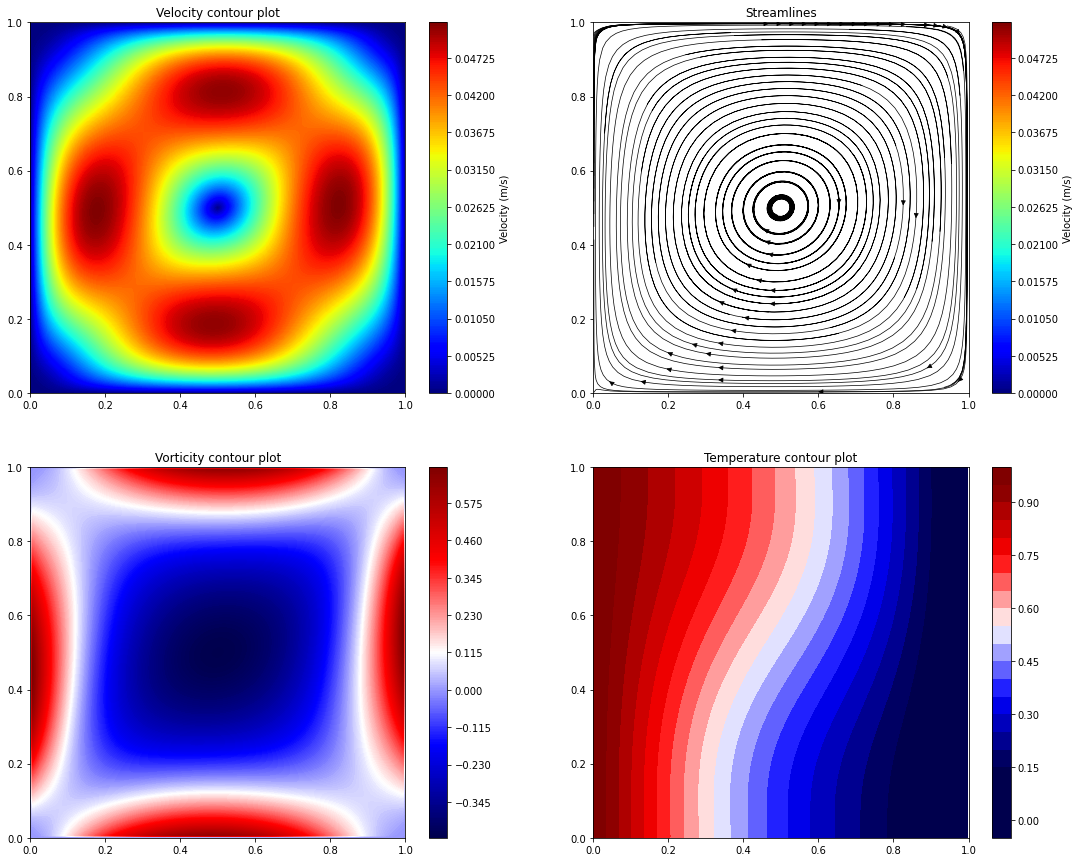

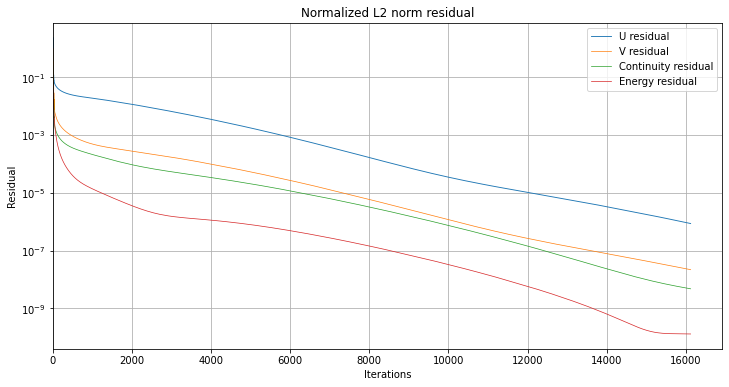

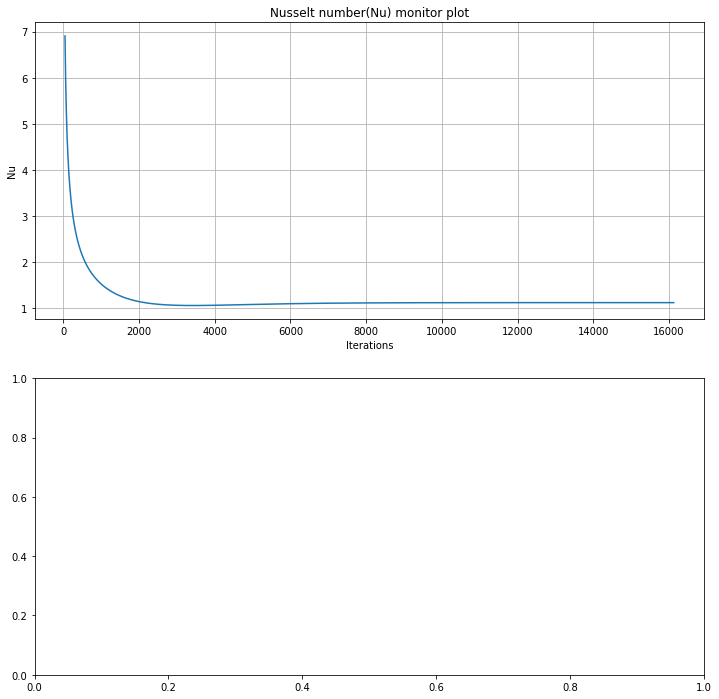

In [74]:
fig,ax=plt.subplots(2,2,figsize=(18.5,15)) #width x height (17 for 5m length, 27 for 8m length)
graph=ax[0][0].contourf(xx,yy,V_mag,cmap=cm.jet,levels=255)
ax[0][0].set_title('Velocity contour plot')
fig.colorbar(graph,ax=ax[0][0],label='Velocity (m/s)')
ax[0][0].set_xlim(0,L)
ax[0][0].set_ylim(0,H)

ax[0][1].streamplot(xx,yy,U_final,V_final,density=1.0,linewidth=0.7,arrowsize=1.0,color='k',broken_streamlines=False)
ax[0][1].set_title('Streamlines')
fig.colorbar(graph,ax=ax[0][1],label='Velocity (m/s)')
ax[0][1].set_xlim(0,L)
ax[0][1].set_ylim(0,H)

graph=ax[1][0].contourf(xx,yy,vort,cmap=cm.seismic,levels=255)
ax[1][0].set_title('Vorticity contour plot')
fig.colorbar(graph,ax=ax[1][0])
ax[1][0].set_xlim(0,L)
ax[1][0].set_ylim(0,H)

graph=ax[1][1].contourf(xx,yy,T_final,levels=20,cmap=cm.seismic,vmax=0.95,vmin=0.15)
ax[1][1].set_title('Temperature contour plot')
fig.colorbar(graph,ax=ax[1][1])
ax[1][1].set_xlim(0,L)
ax[1][1].set_ylim(0,H)
    
plt.show()

iteration_eqn=np.linspace(0,len(U_res_list),len(U_res_list))
iterations=iteration_eqn
if Transient==True:
    iterations=np.linspace(0,len(nu_mean_array),len(nu_mean_array))
    iterations=iterations*dt
    
fig,ax=plt.subplots(1,1,figsize=(12,6))
plt.plot(iteration_eqn[:iter_total-2:],U_res_list[:iter_total-2:],label='U residual',linewidth=0.9)
plt.plot(iteration_eqn[:iter_total-2:],V_res_list[:iter_total-2:],label='V residual',linewidth=0.7)
plt.plot(iteration_eqn[:iter_total-2:],Cont_res_list[:iter_total-2:],label='Continuity residual',linewidth=0.7)
plt.plot(iteration_eqn[:iter_total-2:],T_res_list[:iter_total-2:],label='Energy residual',linewidth=0.7)
plt.xlabel('Iterations')
plt.ylabel('Residual')
plt.title('Normalized L2 norm residual')
ax.set_yscale('log')
plt.grid()
plt.xlim(0)
plt.legend()

plt.show()

fig,ax=plt.subplots(2,1,figsize=(12,12))

ax[0].plot(iterations[50:iter_total-1:],nu_mean_array[50:iter_total-1:])
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('Nu')
ax[0].set_title('Nusselt number(Nu) monitor plot')
ax[0].grid()

if Transient==True:
    ax[1].plot(iterations[50:iter_total-1:],cfl_array[50:iter_total-1:])
    ax[1].set_xlabel('Iterations')
    ax[1].set_ylabel('CFL')
    ax[1].set_title('CFL plot')
    ax[1].grid()

plt.show()

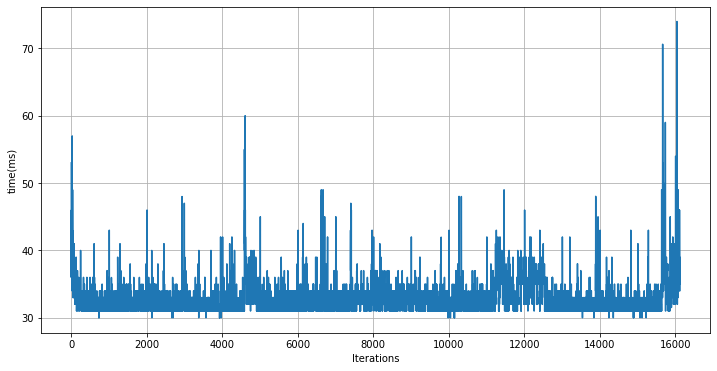

In [75]:
fig,ax=plt.subplots(1,1,figsize=(12,6))
plt.plot(iterations[:iter_total-1],1000*np.array(t_list[:iter_total-1]))
plt.ylabel('time(ms)')
plt.xlabel('Iterations')
plt.grid()
plt.show()

In [57]:
@njit
def nodal_restriction(phi,Ny_f,Nx_f,Ny_c,Nx_c):
    phi_c=np.zeros((Ny_c,Nx_c))
    
    for j in range(Ny_c):
        for i in range(Nx_c):
            j_fine=2*j
            i_fine=2*i
            phi_c[j][i]=0.25*(phi[j_fine][i_fine]+phi[j_fine][i_fine+1]+phi[j_fine+1][i_fine]+phi[j_fine+1][i_fine+1])
            
    return phi_c

U_data=np.load('U_RBC.npy')
V_data=np.load('V_RBC.npy')
T_data=np.load('T_RBC.npy')

In [67]:
len(U_data)

1000

In [68]:
U_data[0].shape

(192, 192)

In [70]:
U_anim=U_data
V_anim=V_data
T_anim=T_data

count=len(U_data)

U_file=[]
V_file=[]
T_file=[]
V_mag_file=[]
Vort_file=[]

for k in range(count):
    Ny_f=int(Ny/2)
    Nx_f=int(Nx/2)
    
    U_fine=U_anim[k]
    V_fine=V_anim[k]
    T_fine=T_anim[k]

#     for n in range(1):
#         Ny_c=int(Ny_f/2)
#         Nx_c=int(Nx_f/2)
        
#         U_coarse=nodal_restriction(U_fine,Ny_f,Nx_f,Ny_c,Nx_c)
#         V_coarse=nodal_restriction(V_fine,Ny_f,Nx_f,Ny_c,Nx_c)
#         T_coarse=nodal_restriction(T_fine,Ny_f,Nx_f,Ny_c,Nx_c)

#         U_fine=U_coarse
#         V_fine=V_coarse
        
#         Ny_f=Ny_c
#         Nx_f=Nx_c

    U_coarse=U_fine
    V_coarse=V_fine
    T_coarse=T_fine
            
    V_mag=np.sqrt(np.power(U_coarse,2)+np.power(V_coarse,2))           
    vort=curl(U_coarse,V_coarse,4*dx,4*dy,int(Nx/4),int(Ny/4))
            
    U_file.append(U_coarse)
    V_file.append(V_coarse)
    T_file.append(T_coarse)
    V_mag_file.append(V_mag)
    Vort_file.append(vort)
    
    if k%50==0:
        print(k)
    if k==999:
        break

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950


In [71]:
len(U_file)

1000

In [72]:
len(T_file)

1000

In [73]:
U_file[0].shape

(192, 192)

In [102]:
def animate(k):
    ax.clear()
    
    U_final=U_file[k]
    V_final=V_file[k]
    #T_final=T_file[k]
    #vort=Vort_file[k]
    #V_mag=V_mag_file[k]
    plt.title('Flow time: '+str(round(k*dt*80,5))+' seconds')
    #plt.title('Streamlines')
    #plt.title('Flow time: '+str(round(k*dt*2,4))+' seconds')
    
    plt.xlim(0,L)
    plt.ylim(0,H)
    #contour=plt.contourf(xx,yy,V_mag,cmap=cm.jet,vmax=1,levels=255)
    #contour=plt.contourf(xx,yy,T_final,cmap=cm.seismic,vmax=0.8,vmin=0.2,levels=50)
    #contour=plt.contourf(xx,yy,vort,cmap=cm.seismic,vmax=2500,vmin=-2500,levels=255)
    stream=plt.streamplot(xx,yy,U_final,V_final,linewidth=0.8,density=0.6,color='k',arrowsize=1.0,broken_streamlines=False)
    return stream

<IPython.core.display.Javascript object>


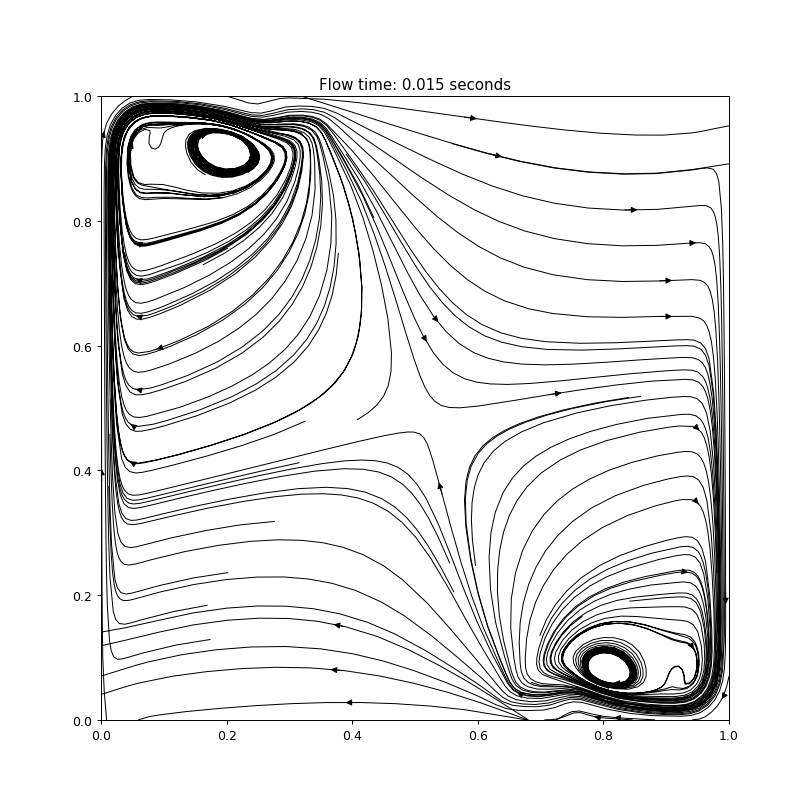

In [103]:
fig,ax=plt.subplots(1,1,figsize=(9,9))
plt.xlim(0,L)
plt.ylim(0,H)
x=np.linspace(0,L,192)
y=np.linspace(0,H,192)
xx,yy=np.meshgrid(x,y)

ani=FuncAnimation(fig,animate,count,interval=500, blit=True)
plt.show()